<a href="https://colab.research.google.com/github/arc23frm/steamgames-dataset-klustering-with-kmeans-kmedoids/blob/main/FINAL-CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FASE 1 SECTION A - SETUP & KONFIGURASI

In [ ]:
#A.1 Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# A.2 - Struktur Folder
import os
BASE_PATH = '/content/drive/MyDrive/skripsi_steam/'
FOLDERS = {
    'data_mentah'            : BASE_PATH + '01_data_mentah/',
    'checkpoints_filtering'  : BASE_PATH + '02_checkpoints_filtering/',
    'preprocessing'          : BASE_PATH + '03_preprocessing/',
    'model'                  : BASE_PATH + '04_model/',
    'clustering'             : BASE_PATH + '05_clustering/',
    'bukti_proses'           : BASE_PATH + '06_bukti_proses/',
    'visualisasi'            : BASE_PATH + '07_visualisasi/',
    'output_final'           : BASE_PATH + '08_output_final/',
}
MANIFEST_PATH = BASE_PATH + 'manifest.csv'
LOG_PATH      = BASE_PATH + 'log_eksekusi_pipeline.csv'
for nama, path in FOLDERS.items():
    os.makedirs(path, exist_ok=True)
print("Struktur folder berhasil dibuat/diverifikasi:")
for nama, path in FOLDERS.items():
    status = "OK" if os.path.isdir(path) else "GAGAL"
    print(f"  [{status}] {nama:22s} -> {path}")

Struktur folder berhasil dibuat/diverifikasi:
  [OK] data_mentah            -> /content/drive/MyDrive/skripsi_steam/01_data_mentah/
  [OK] checkpoints_filtering  -> /content/drive/MyDrive/skripsi_steam/02_checkpoints_filtering/
  [OK] preprocessing          -> /content/drive/MyDrive/skripsi_steam/03_preprocessing/
  [OK] model                  -> /content/drive/MyDrive/skripsi_steam/04_model/
  [OK] clustering             -> /content/drive/MyDrive/skripsi_steam/05_clustering/
  [OK] bukti_proses           -> /content/drive/MyDrive/skripsi_steam/06_bukti_proses/
  [OK] visualisasi            -> /content/drive/MyDrive/skripsi_steam/07_visualisasi/
  [OK] output_final           -> /content/drive/MyDrive/skripsi_steam/08_output_final/


In [ ]:
#A.3 Install & Import Library
!pip install -q kaggle tabulate kmedoids
import pandas as pd
import numpy as np
import json
import ast
from datetime import datetime
from tabulate import tabulate
import joblib
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("Library siap digunakan: pandas, numpy, tabulate, joblib, kmedoids")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 12.8 MB/s eta 0:00:00
Library siap digunakan: pandas, numpy, tabulate, joblib, kmedoids


In [ ]:
#A.4 Formatting

LINE    = "=" * 78
SUBLINE = "-" * 78

def header(title, subtitle=None):
    print(LINE)
    print(f" {title}")
    if subtitle:
        print(f" {subtitle}")
    print(LINE)
def section(title):
    print(f"\n{SUBLINE}")
    print(f" {title}")
    print(SUBLINE)
def kv_table(d):
    rows = [[k, v] for k, v in d.items()]
    print(tabulate(rows, headers=["Keterangan", "Nilai"], tablefmt="grid"))
def df_table(df, floatfmt=".2f", showindex=True):
    print(tabulate(df, headers='keys', tablefmt='grid', floatfmt=floatfmt, showindex=showindex))
def footer(note=None, saved_to=None):
    print(SUBLINE)
    if saved_to:
        print(f" Output disimpan : {saved_to}")
    if note:
        print(f" Catatan         : {note}")
    print(f" Waktu eksekusi  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(LINE + "\n")
# CHECKPOINT
def simpan_checkpoint(df, folder_key, nama_file):
    path = FOLDERS[folder_key] + nama_file
    df.to_csv(path, index=True)
    return path
def muat_checkpoint(folder_key, nama_file, kolom_list_literal=None):
    path = FOLDERS[folder_key] + nama_file
    df = pd.read_csv(path, index_col=0)
    if kolom_list_literal:
        for kol in kolom_list_literal:
            if kol in df.columns:
                df[kol] = df[kol].apply(
                    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
                )
    return df

In [ ]:
#A.5 Fungsi Manifest, Log, Bukti Proses

def tulis_manifest(tahap, nama_file, path_file, df, deskripsi):
    baris = pd.DataFrame([{
        'tahap'          : tahap,
        'nama_file'      : nama_file,
        'path'           : path_file,
        'jumlah_baris'   : len(df),
        'jumlah_kolom'   : df.shape[1],
        'deskripsi'      : deskripsi,
        'waktu_dibuat'   : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),}])
    header_diperlukan = not os.path.exists(MANIFEST_PATH)
    baris.to_csv(MANIFEST_PATH, mode='a', header=header_diperlukan, index=False)
def tulis_log(tahap, keterangan, baris_masuk, baris_keluar):
    baris = pd.DataFrame([{
        'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'tahap'         : tahap,
        'keterangan'    : keterangan,
        'baris_masuk'   : baris_masuk,
        'baris_keluar'  : baris_keluar,}])
    header_diperlukan = not os.path.exists(LOG_PATH)
    baris.to_csv(LOG_PATH, mode='a', header=header_diperlukan, index=False)
def simpan_bukti_proses(nama_file, dict_ringkasan):
    path = FOLDERS['bukti_proses'] + nama_file
    df_bukti = pd.DataFrame([dict_ringkasan])
    df_bukti.to_csv(path, index=False)
    return path
print("Fungsi utilitas siap digunakan.")

Fungsi utilitas siap digunakan.


In [ ]:
#A.6 Ringkasan Penutup
header("SECTION A SELESAI — SETUP & KONFIGURASI",
       "Drive ter-mount, struktur folder siap, fungsi utilitas siap")
section("Struktur Folder Aktif")
kv_table({nama: path for nama, path in FOLDERS.items()})
footer(note="Lanjut ke SECTION B — Akuisisi Dataset", saved_to=BASE_PATH)

 SECTION A SELESAI — SETUP & KONFIGURASI
 Drive ter-mount, struktur folder siap, fungsi utilitas siap

------------------------------------------------------------------------------
 Struktur Folder Aktif
------------------------------------------------------------------------------
+-----------------------+----------------------------------------------------------------+
| Keterangan            | Nilai                                                          |
+=======================+================================================================+
| data_mentah           | /content/drive/MyDrive/skripsi_steam/01_data_mentah/           |
+-----------------------+----------------------------------------------------------------+
| checkpoints_filtering | /content/drive/MyDrive/skripsi_steam/02_checkpoints_filtering/ |
+-----------------------+----------------------------------------------------------------+
| preprocessing         | /content/drive/MyDrive/skripsi_steam/03_preprocessing

FASE 2 SECTION B - AKUISISI DATASET

In [ ]:
#B.1 DOWNLOAD DATASET KAGGLE
path_lock_raw = FOLDERS['data_mentah'] + '00_raw_dataset.csv'
if os.path.exists(path_lock_raw):
    print("Dataset mentah SUDAH TERKUNCI (checkpoint).")
    print(f"Path: {path_lock_raw}")
else:
    import kagglehub
    path_dataset = kagglehub.dataset_download("fronkongames/steam-games-dataset")
    print("Path dataset:", path_dataset)
    print("Isi folder  :", os.listdir(path_dataset))
    import shutil
    shutil.copy(f"{path_dataset}/games.json", "games.json")
    print("games.json berhasil diunduh")

Dataset mentah SUDAH TERKUNCI (checkpoint).
Path: /content/drive/MyDrive/skripsi_steam/01_data_mentah/00_raw_dataset.csv


In [ ]:
#B.2 Summary dataset
if os.path.exists(path_lock_raw):
    df = muat_checkpoint('data_mentah', '00_raw_dataset.csv',
                          kolom_list_literal=['genres', 'categories', 'tags'])
else:
    with open('games.json', 'r', encoding='utf-8') as f:
        data_json = json.load(f)
    df = pd.DataFrame.from_dict(data_json, orient='index')
    df.index.name = 'AppID'
# Hitung info per kolom: tipe data, jumlah missing, persentase missing
info_kolom = pd.DataFrame({
    'tipe_data'      : df.dtypes.astype(str),
    'jumlah_missing' : df.isna().sum(),
    'persen_missing' : (df.isna().mean() * 100).round(2),
})
# Hitung statistik ringkas dataset (ukuran memori, duplikat index awal)
memori_mb = df.memory_usage(deep=True).sum() / 1024**2
jumlah_duplikat_appid = df.index.duplicated().sum()
# Siapkan preview 20
pd.set_option('display.max_columns', None)
MAX_CHAR = 30
df_preview = df.head(20).copy()
for kol in df_preview.columns:
    if df_preview[kol].dtype == 'object':
        df_preview[kol] = df_preview[kol].apply(
            lambda x: (str(x)[:MAX_CHAR] + '...') if isinstance(x, str) and len(str(x)) > MAX_CHAR else x)

In [ ]:
# Judul section
header("SECTION B — AKUISISI DATASET",
       "Load games.json -> pandas DataFrame -> TERKUNCI sebagai checkpoint 00_raw_dataset.csv")
# Status sumber data
section("Status Dataset")
if os.path.exists(path_lock_raw):
    kv_table({"Status": "Dimuat dari checkpoint TERKUNCI"})
else:
    kv_table({"Status": "Dimuat baru dari games.json (belum pernah dikunci sebelumnya)",
              "Jumlah game (raw JSON)": f"{len(data_json):,}"})
# Struktur DataFrame + statistik ringkas (hasil dari P3)
section("Struktur DataFrame")
kv_table({
    "Shape"                    : f"{df.shape[0]:,} baris x {df.shape[1]} kolom",
    "Jumlah kolom"             : len(df.columns),
    "Penggunaan memori"        : f"{memori_mb:,.2f} MB",
    "Duplikat AppID (index)"   : f"{jumlah_duplikat_appid:,}",
})

 SECTION B — AKUISISI DATASET
 Load games.json -> pandas DataFrame -> TERKUNCI sebagai checkpoint 00_raw_dataset.csv

------------------------------------------------------------------------------
 Status Dataset
------------------------------------------------------------------------------
+--------------+---------------------------------+
| Keterangan   | Nilai                           |
+==============+=================================+
| Status       | Dimuat dari checkpoint TERKUNCI |
+--------------+---------------------------------+

------------------------------------------------------------------------------
 Struktur DataFrame
------------------------------------------------------------------------------
+------------------------+--------------------------+
| Keterangan             | Nilai                    |
+========================+==========================+
| Shape                  | 136,080 baris x 42 kolom |
+------------------------+--------------------------+
| Ju

In [ ]:
# Daftar seluruh kolom, tipe data, dan missing value (hasil dari P2)
section("Daftar Seluruh Kolom, Tipe Data & Missing Value")
df_table(info_kolom, showindex=True)


------------------------------------------------------------------------------
 Daftar Seluruh Kolom, Tipe Data & Missing Value
------------------------------------------------------------------------------
+--------------------------+-------------+------------------+------------------+
|                          | tipe_data   |   jumlah_missing |   persen_missing |
+==========================+=============+==================+==================+
| name                     | object      |                1 |             0.00 |
+--------------------------+-------------+------------------+------------------+
| release_date             | object      |                0 |             0.00 |
+--------------------------+-------------+------------------+------------------+
| required_age             | int64       |                0 |             0.00 |
+--------------------------+-------------+------------------+------------------+
| price                    | float64     |                0 |  

In [ ]:
# Ringkasan kolom paling banyak missing
section("5 Kolom dengan Missing Value Terbanyak")
top_missing = info_kolom.sort_values('jumlah_missing', ascending=False).head(5)
df_table(top_missing, showindex=True)


------------------------------------------------------------------------------
 5 Kolom dengan Missing Value Terbanyak
------------------------------------------------------------------------------
+----------------+-------------+------------------+------------------+
|                | tipe_data   |   jumlah_missing |   persen_missing |
+================+=============+==================+==================+
| score_rank     | float64     |           136040 |            99.97 |
+----------------+-------------+------------------+------------------+
| metacritic_url | object      |           131811 |            96.86 |
+----------------+-------------+------------------+------------------+
| reviews        | object      |           123616 |            90.84 |
+----------------+-------------+------------------+------------------+
| notes          | object      |           110343 |            81.09 |
+----------------+-------------+------------------+------------------+
| website        | o

In [ ]:
# Preview 20 baris
section("Seluruh Kolom")
df_table(df_preview)


------------------------------------------------------------------------------
 Seluruh Kolom
------------------------------------------------------------------------------
+---------+-------------------------------------+----------------+----------------+---------+-------------+-------------------------------------+-------------------------------------+-----------------------------------+-----------------------------------+-----------------------------------+-----------------------------------+-----------------------------------+------------------------------+-----------+-------+---------+--------------------+-----------------------------------+----------------+-------------------+-----------------------------------+-----------------------------------+-----------------------------------+-------------------------------------------+-----------------------------------+-----------------------------------+------------------------------------------------------------------------------------

In [ ]:
#B.3 LOGGING DATA

if not os.path.exists(path_lock_raw):
    path_tersimpan = simpan_checkpoint(df, 'data_mentah', '00_raw_dataset.csv')
    # File Terkunci (tetap)
    df_lock_info = pd.DataFrame([{
        'nama_dataset'     : 'fronkongames/steam-games-dataset',
        'file_checkpoint'  : '00_raw_dataset.csv',
        'jumlah_baris'     : len(df),
        'jumlah_kolom'     : df.shape[1],
        'waktu_dikunci'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'status'           : 'TERKUNCI - OK',}])
    df_lock_info.to_csv(BASE_PATH + 'dataset_lock.csv', index=False)
    simpan_bukti_proses('bukti_00_akuisisi_data.csv', {
        'tahap'               : '0. Akuisisi Data',
        'jumlah_baris_df'     : len(df),
        'jumlah_kolom_df'     : df.shape[1],
        'sumber_dataset'      : 'Kaggle: fronkongames/steam-games-dataset',
        'waktu_eksekusi'      : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
    tulis_manifest(
        tahap       = '0. Akuisisi Data',
        nama_file   = '00_raw_dataset.csv',
        path_file   = path_tersimpan,
        df          = df,
        deskripsi   = 'Snapshot mentah dataset Steam dari Kaggle (TERKUNCI), sebelum filtering')
    tulis_log(
        tahap        = '0. Akuisisi Data',
        keterangan   = 'Load games.json ke DataFrame, KUNCI sebagai checkpoint awal',
        baris_masuk  = len(data_json),
        baris_keluar = len(df))
    footer(note="Dataset BARU dikunci",
           saved_to=path_tersimpan)
else:
    footer(note="Dataset SUDAH terkunci sebelumnya — tidak ada perubahan pada checkpoint.",
           saved_to=path_lock_raw)

------------------------------------------------------------------------------
 Output disimpan : /content/drive/MyDrive/skripsi_steam/01_data_mentah/00_raw_dataset.csv
 Catatan         : Dataset SUDAH terkunci sebelumnya — tidak ada perubahan pada checkpoint.
 Waktu eksekusi  : 2026-08-10 06:03:28



FASE 3 SECTION C — FILTERING LEVEL 1 (Real Game Filter)


In [ ]:
# PROSES LOGIKA FILTERING LEVEL 1 (Real Game Filter)
# P1 — Muat data dari checkpoint
df = muat_checkpoint('data_mentah', '00_raw_dataset.csv',
                      kolom_list_literal=['genres', 'categories', 'tags'])
baris_awal = len(df)
# P2 — Definisi kriteria filter
NON_GAME_GENRES = {'Utilities', 'Software Training', 'Design & Illustration',
                    'Audio Production', 'Video Production', 'Photo Editing',
                    'Game Development', 'Animation & Modeling', 'Web Publishing', 'Accounting'}
TEST_PATTERN = r'playtest|\bdemo\b|\bbeta\b|\balpha\b|prototype|tech test|stress test'
# P3 — Terapkan 3 kriteria filter
is_non_game_genre = df['genres'].apply(
    lambda g: bool(NON_GAME_GENRES & set(g)) if isinstance(g, list) else False)
is_test_version = df['name'].str.contains(TEST_PATTERN, case=False, na=False, regex=True)
is_empty_listing = (
    df[['detailed_description', 'about_the_game', 'short_description']]
        .apply(lambda col: col.str.strip().eq('')).all(axis=1)
    & df['genres'].apply(lambda g: len(g) == 0 if isinstance(g, list) else True)
    & df['categories'].apply(lambda c: len(c) == 0 if isinstance(c, list) else True))
df['is_not_real_game'] = is_non_game_genre | is_test_version | is_empty_listing
jumlah_overlap = ((is_non_game_genre.astype(int) + is_test_version.astype(int) + is_empty_listing.astype(int)) > 1).sum()
# P4 — Hasilkan dataset bersih (baris yang lolos filter)
df_stage_a = df[~df['is_not_real_game']].copy()
baris_akhir = len(df_stage_a)
df_stage_a = df_stage_a.drop(columns=['is_not_real_game'])
# P5 — Simpan checkpoint
path_tersimpan_filter = simpan_checkpoint(df_stage_a, 'checkpoints_filtering', '01_filter_level1_realgame.csv')
# P6 — Catat manifest, log, bukti proses
simpan_bukti_proses('bukti_01_filtering_level1.csv', {
    'tahap': '1. Filtering Level 1 - Real Game Filter', 'baris_masuk': baris_awal,
    'dibuang_genre_non_game': int(is_non_game_genre.sum()),
    'dibuang_versi_uji_coba': int(is_test_version.sum()),
    'dibuang_listing_kosong': int(is_empty_listing.sum()),
    'overlap_multi_kriteria': int(jumlah_overlap), 'baris_keluar': baris_akhir,
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
tulis_manifest(tahap='1. Filtering Level 1', nama_file='01_filter_level1_realgame.csv',
    path_file=path_tersimpan_filter, df=df_stage_a,
    deskripsi='Real Game Filter: buang genre non-game, versi uji coba, listing kosong total')
tulis_log(tahap='1. Filtering Level 1',
    keterangan='Real Game Filter - gabungan 3 kriteria', baris_masuk=baris_awal, baris_keluar=baris_akhir)

TAMPILAN OUTPUT FILTERING (Real Game Filter)

In [ ]:
# T1 — Judul section
header("SECTION C — FILTERING LEVEL 1 (REAL GAME FILTER)",
       "Input: 00_raw_dataset.csv -> Output: 01_filter_level1_realgame.csv")
# T2 — Info data masuk
section("Status Data Masuk")
kv_table({"Sumber": "01_data_mentah/00_raw_dataset.csv", "Jumlah baris": f"{len(df):,}", "Jumlah kolom": df.shape[1]})

 SECTION C — FILTERING LEVEL 1 (REAL GAME FILTER)
 Input: 00_raw_dataset.csv -> Output: 01_filter_level1_realgame.csv

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+-----------------------------------+
| Keterangan   | Nilai                             |
+==============+===================================+
| Sumber       | 01_data_mentah/00_raw_dataset.csv |
+--------------+-----------------------------------+
| Jumlah baris | 136,080                           |
+--------------+-----------------------------------+
| Jumlah kolom | 43                                |
+--------------+-----------------------------------+


In [ ]:
# T3 — Tampilkan kriteria yang dipakai
section("Kriteria Filtering yang Digunakan")
kv_table({
    "Filter 1 - Genre non-game": f"{len(NON_GAME_GENRES)} genre software/tools",
    "Filter 2 - Versi uji coba": TEST_PATTERN,
    "Filter 3 - Listing kosong": "deskripsi DAN genres DAN categories kosong",})
# T4 — Ringkasan angka hasil filter
section("Rincian Alasan Pembuangan")
kv_table({
    "Genre non-game": f"{is_non_game_genre.sum():,} baris",
    "Versi uji coba": f"{is_test_version.sum():,} baris",
    "Listing kosong": f"{is_empty_listing.sum():,} baris",
    "Overlap (>1 kriteria)": f"{jumlah_overlap:,} baris",
    "TOTAL dibuang": f"{df['is_not_real_game'].sum():,} baris",})
section("Hasil Akhir Tahap 1")
kv_table({
    "Baris awal": f"{baris_awal:,}", "Baris tersisa": f"{baris_akhir:,}",
    "Baris dibuang": f"{baris_awal - baris_akhir:,}", "Persentase lolos": f"{baris_akhir/baris_awal*100:.2f}%",
})


------------------------------------------------------------------------------
 Kriteria Filtering yang Digunakan
------------------------------------------------------------------------------
+---------------------------+----------------------------------------------------------------------+
| Keterangan                | Nilai                                                                |
+===========================+======================================================================+
| Filter 1 - Genre non-game | 10 genre software/tools                                              |
+---------------------------+----------------------------------------------------------------------+
| Filter 2 - Versi uji coba | playtest|\bdemo\b|\bbeta\b|\balpha\b|prototype|tech test|stress test |
+---------------------------+----------------------------------------------------------------------+
| Filter 3 - Listing kosong | deskripsi DAN genres DAN categories kosong                           

In [ ]:
# T5 — Contoh baris dibuang & lolos
pd.set_option('display.max_columns', None)
MAX_CHAR = 30
def potong(df_in, kolom):
    df_out = df_in[kolom].head(5).copy()
    for k in df_out.columns:
        if df_out[k].dtype == 'object':
            df_out[k] = df_out[k].apply(lambda x: (str(x)[:MAX_CHAR] + '...') if isinstance(x, str) and len(str(x)) > MAX_CHAR else x)
    return df_out
kolom_contoh = [k for k in ['name', 'genres', 'categories'] if k in df.columns]
section("Contoh Baris yang Dibuang")
if is_non_game_genre.sum() > 0:
    print("Genre non-game:"); df_table(potong(df[is_non_game_genre], kolom_contoh))
if is_test_version.sum() > 0:
    print("Versi uji coba:"); df_table(potong(df[is_test_version], kolom_contoh))
if is_empty_listing.sum() > 0:
    print("Listing kosong:"); df_table(potong(df[is_empty_listing], kolom_contoh))
section("Contoh Baris yang Lolos")
kolom_preview = [k for k in ['name', 'release_date', 'price', 'genres', 'categories'] if k in df_stage_a.columns]
df_table(df_stage_a[kolom_preview].head(10))
# T6 — Penutup section
footer(note="Lanjut ke SECTION D", saved_to=path_tersimpan_filter)


------------------------------------------------------------------------------
 Contoh Baris yang Dibuang
------------------------------------------------------------------------------
Genre non-game:
+---------+-----------------------------------+-----------------------------------------------------------------------+-------------------------------------------------------------------------+
|   AppID | name                              | genres                                                                | categories                                                              |
+=========+===================================+=======================================================================+=========================================================================+
|  496910 | DrumKit VR - Play drum kit in ... | ['Audio Production']                                                  | ['Tracked Controller Support', 'VR Only']                               |
+---------+-----------

FASE 3 SECTION D - FILTERING LEVEL 2 (Popularitas Ketat)

In [ ]:
# PROSES LOGIKA FILTERING LEVEL 2 (Popularitas Ketat)
# P1 — Muat data dari checkpoint Level 1
df_stage_a = muat_checkpoint('checkpoints_filtering', '01_filter_level1_realgame.csv',
                              kolom_list_literal=['genres', 'categories', 'tags'])
baris_masuk = len(df_stage_a)
# P2 — Hitung metrik popularitas (kolom turunan baru)
def owners_to_numeric(x):
    try:
        low, high = map(int, x.split(' - '))
        return (low + high) / 2
    except:
        return np.nan
df_stage_a['estimated_owners_numeric'] = df_stage_a['estimated_owners'].apply(owners_to_numeric)
df_stage_a['total_reviews'] = df_stage_a['positive'] + df_stage_a['negative']
# P3 — Terapkan cross-validation popularitas
MIN_REVIEWS = 10
syarat_owners = df_stage_a['estimated_owners_numeric'] > 0
syarat_reviews = df_stage_a['total_reviews'] >= MIN_REVIEWS
valid_popularity = syarat_owners & syarat_reviews
# P4 — Hasilkan dataset bersih (baris yang lolos filter)
df_stage_b = df_stage_a[valid_popularity].copy()
baris_keluar = len(df_stage_b)
# P5 — Simpan checkpoint
path_tersimpan_pop = simpan_checkpoint(df_stage_b, 'checkpoints_filtering', '02_filter_level2_popularitas.csv')

# P6 — Catat manifest, log, bukti proses
simpan_bukti_proses('bukti_02_filtering_level2.csv', {
    'tahap': '2. Filtering Level 2 - Popularitas Ketat', 'min_reviews': MIN_REVIEWS,
    'baris_masuk': baris_masuk, 'lolos_owners_saja': int(syarat_owners.sum()),
    'lolos_reviews_saja': int(syarat_reviews.sum()), 'lolos_kedua_syarat': int(valid_popularity.sum()),
    'baris_keluar': baris_keluar, 'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
})
tulis_manifest(tahap='2. Filtering Level 2', nama_file='02_filter_level2_popularitas.csv',
    path_file=path_tersimpan_pop, df=df_stage_b,
    deskripsi=f'Popularitas Ketat: cross-validation owners > 0 DAN total_reviews >= {MIN_REVIEWS}')
tulis_log(tahap='2. Filtering Level 2',
    keterangan=f'Popularitas Ketat - cross-validation owners & reviews (min_reviews={MIN_REVIEWS})',
    baris_masuk=baris_masuk, baris_keluar=baris_keluar)

TAMPILAN OUTPUT FILTERING LEVEL 2 (Popularitas Ketat)

In [ ]:
# T1 — Judul section
header("SECTION D — FILTERING LEVEL 2 (POPULARITAS KETAT)",
       "Input: 01_filter_level1_realgame.csv -> Output: 02_filter_level2_popularitas.csv")
# T2 — Info data masuk
section("Status Data Masuk")
kv_table({"Sumber": "02_checkpoints_filtering/01_filter_level1_realgame.csv",
          "Jumlah baris": f"{len(df_stage_a):,}", "Jumlah kolom": df_stage_a.shape[1]})

 SECTION D — FILTERING LEVEL 2 (POPULARITAS KETAT)
 Input: 01_filter_level1_realgame.csv -> Output: 02_filter_level2_popularitas.csv

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+--------------------------------------------------------+
| Keterangan   | Nilai                                                  |
+==============+========================================================+
| Sumber       | 02_checkpoints_filtering/01_filter_level1_realgame.csv |
+--------------+--------------------------------------------------------+
| Jumlah baris | 125,861                                                |
+--------------+--------------------------------------------------------+
| Jumlah kolom | 44                                                     |
+--------------+--------------------------------------------------------+


In [ ]:
# T3 — Statistik distribusi sebelum filter
section("Persiapan Metrik Popularitas")
kv_table({
    "estimated_owners_numeric - min": f"{df_stage_a['estimated_owners_numeric'].min():,.0f}",
    "estimated_owners_numeric - median": f"{df_stage_a['estimated_owners_numeric'].median():,.0f}",
    "estimated_owners_numeric - max": f"{df_stage_a['estimated_owners_numeric'].max():,.0f}",
    "estimated_owners_numeric - NaN": f"{df_stage_a['estimated_owners_numeric'].isna().sum():,}",
    "total_reviews - min": f"{df_stage_a['total_reviews'].min():,.0f}",
    "total_reviews - median": f"{df_stage_a['total_reviews'].median():,.0f}",
    "total_reviews - max": f"{df_stage_a['total_reviews'].max():,.0f}",
})


------------------------------------------------------------------------------
 Persiapan Metrik Popularitas
------------------------------------------------------------------------------
+-----------------------------------+-------------+
| Keterangan                        | Nilai       |
+===================================+=============+
| estimated_owners_numeric - min    | 0           |
+-----------------------------------+-------------+
| estimated_owners_numeric - median | 10,000      |
+-----------------------------------+-------------+
| estimated_owners_numeric - max    | 150,000,000 |
+-----------------------------------+-------------+
| estimated_owners_numeric - NaN    | 0           |
+-----------------------------------+-------------+
| total_reviews - min               | 0           |
+-----------------------------------+-------------+
| total_reviews - median            | 6           |
+-----------------------------------+-------------+
| total_reviews - max          

In [ ]:
# T4 — Ringkasan hasil validasi
section("Validasi Dua Sumber Independen")
kv_table({
    "Lolos syarat owners > 0 saja": f"{syarat_owners.sum():,}",
    f"Lolos syarat review >= {MIN_REVIEWS} saja": f"{syarat_reviews.sum():,}",
    "Lolos KEDUA syarat (final)": f"{valid_popularity.sum():,}",
    "Gugur - owners tidak valid saja": f"{(~syarat_owners & syarat_reviews).sum():,}",
    "Gugur - review kurang saja": f"{(syarat_owners & ~syarat_reviews).sum():,}",
    "Gugur - keduanya tidak memenuhi": f"{(~syarat_owners & ~syarat_reviews).sum():,}",})
section("Hasil Akhir Tahap 2")
kv_table({
    "Baris masuk": f"{baris_masuk:,}", "Baris tersisa": f"{baris_keluar:,}",
    "Baris dibuang": f"{baris_masuk - baris_keluar:,}", "Persentase lolos": f"{baris_keluar/baris_masuk*100:.2f}%",})



------------------------------------------------------------------------------
 Validasi Dua Sumber Independen
------------------------------------------------------------------------------
+---------------------------------+---------+
| Keterangan                      | Nilai   |
+=================================+=========+
| Lolos syarat owners > 0 saja    | 100,893 |
+---------------------------------+---------+
| Lolos syarat review >= 10 saja  | 55,708  |
+---------------------------------+---------+
| Lolos KEDUA syarat (final)      | 55,708  |
+---------------------------------+---------+
| Gugur - owners tidak valid saja | 0       |
+---------------------------------+---------+
| Gugur - review kurang saja      | 45,185  |
+---------------------------------+---------+
| Gugur - keduanya tidak memenuhi | 24,968  |
+---------------------------------+---------+

------------------------------------------------------------------------------
 Hasil Akhir Tahap 2
------------------

In [ ]:
# T5 — Contoh baris gugur & lolos
pd.set_option('display.max_columns', None)
MAX_CHAR = 30
def potong(df_in, kolom, n=5):
    df_out = df_in[kolom].head(n).copy()
    for k in df_out.columns:
        if df_out[k].dtype == 'object':
            df_out[k] = df_out[k].apply(lambda x: (str(x)[:MAX_CHAR] + '...') if isinstance(x, str) and len(str(x)) > MAX_CHAR else x)
    return df_out
section("Contoh Baris yang Gugur")
kolom_contoh = [k for k in ['name', 'estimated_owners', 'estimated_owners_numeric', 'total_reviews'] if k in df_stage_a.columns]
df_table(potong(df_stage_a[~valid_popularity], kolom_contoh))
section("Contoh Baris yang Lolos")
kolom_preview = [k for k in ['name', 'estimated_owners', 'estimated_owners_numeric',
                             'positive', 'negative', 'total_reviews', 'price'] if k in df_stage_b.columns]
df_table(potong(df_stage_b, kolom_preview, n=10))
# T6 — Penutup section
footer(note="Lanjut ke SECTION E", saved_to=path_tersimpan_pop)


------------------------------------------------------------------------------
 Contoh Baris yang Gugur
------------------------------------------------------------------------------
+---------+-------------------------------------+--------------------+----------------------------+-----------------+
|   AppID | name                                | estimated_owners   |   estimated_owners_numeric |   total_reviews |
+=========+=====================================+====================+============================+=================+
| 3292190 | 버튜버 파라노이아 - Vtuber Paranoia | 0 - 20000          |                   10000.00 |               0 |
+---------+-------------------------------------+--------------------+----------------------------+-----------------+
| 3631080 | Maze Quest VR                       | 0 - 20000          |                   10000.00 |               0 |
+---------+-------------------------------------+--------------------+----------------------------+-----------------

FASE 3 SECTION E - FILTERING LEVEL 3 (Validasi Waktu Bermain)

In [ ]:
# PROSES LOGIKA FILTERING LEVEL 3 (Validasi Waktu Bermain)
# P1 — Muat data dari checkpoint Level 2
df_stage_b = muat_checkpoint('checkpoints_filtering', '02_filter_level2_popularitas.csv',
                              kolom_list_literal=['genres', 'categories', 'tags'])
baris_masuk = len(df_stage_b)
KOLOM_PLAYTIME = ['average_playtime_forever', 'average_playtime_2weeks',
                  'median_playtime_forever', 'median_playtime_2weeks']
# P2 — Terapkan 3 kriteria validasi playtime
is_valid_range = (df_stage_b[KOLOM_PLAYTIME] >= 0).all(axis=1)
is_konsisten_average = df_stage_b['average_playtime_forever'] >= df_stage_b['average_playtime_2weeks']
is_konsisten_median  = df_stage_b['median_playtime_forever'] >= df_stage_b['median_playtime_2weeks']
is_logically_consistent = is_konsisten_average & is_konsisten_median
is_active = df_stage_b['average_playtime_forever'] > 0
# P3 — Gabungkan kriteria (integritas + konsistensi) DAN aktivitas nyata
valid_data = is_valid_range & is_logically_consistent
valid_playtime = valid_data & is_active
# P4 — Hasilkan dataset bersih (baris yang lolos filter)
df_stage_c = df_stage_b[valid_playtime].copy()
baris_keluar = len(df_stage_c)
# P5 — Simpan checkpoint
path_tersimpan_playtime = simpan_checkpoint(df_stage_c, 'checkpoints_filtering', '03_filter_level3_playtime.csv')
# P6 — Catat manifest, log, bukti proses
simpan_bukti_proses('bukti_03_filtering_level3_playtime.csv', {
    'tahap': '3. Filtering Level 3 - Validasi Waktu Bermain', 'baris_masuk': baris_masuk,
    'lolos_integritas_data': int(is_valid_range.sum()),
    'lolos_konsistensi_logis': int(is_logically_consistent.sum()),
    'lolos_aktivitas_nyata': int(is_active.sum()), 'lolos_kedua_syarat': int(valid_playtime.sum()),
    'baris_keluar': baris_keluar, 'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
tulis_manifest(tahap='3. Filtering Level 3 - Playtime', nama_file='03_filter_level3_playtime.csv',
    path_file=path_tersimpan_playtime, df=df_stage_c,
    deskripsi='Validasi Waktu Bermain: integritas data, konsistensi logis (forever >= 2weeks), aktivitas nyata (forever > 0)')
tulis_log(tahap='3. Filtering Level 3 - Playtime',
    keterangan='Cross-validation playtime - integritas & konsistensi DAN aktivitas nyata',
    baris_masuk=baris_masuk, baris_keluar=baris_keluar)

TAMPILAN OUTPUT FILTERING LEVEL 3 (Validasi Waktu Bermain)

In [ ]:
# T1 — Judul section
header("SECTION E — FILTERING LEVEL 3 (VALIDASI WAKTU BERMAIN)",
       "Input: 02_filter_level2_popularitas.csv -> Output: 03_filter_level3_playtime.csv")
# T2 — Info data masuk
section("Status Data Masuk")
kv_table({"Sumber": "02_checkpoints_filtering/02_filter_level2_popularitas.csv",
          "Jumlah baris": f"{len(df_stage_b):,}", "Jumlah kolom": df_stage_b.shape[1]})

 SECTION E — FILTERING LEVEL 3 (VALIDASI WAKTU BERMAIN)
 Input: 02_filter_level2_popularitas.csv -> Output: 03_filter_level3_playtime.csv

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+-----------------------------------------------------------+
| Keterangan   | Nilai                                                     |
+==============+===========================================================+
| Sumber       | 02_checkpoints_filtering/02_filter_level2_popularitas.csv |
+--------------+-----------------------------------------------------------+
| Jumlah baris | 55,708                                                    |
+--------------+-----------------------------------------------------------+
| Jumlah kolom | 44                                                        |
+--------------+----------------------------------------------------

In [ ]:
# T3 — Statistik distribusi sebelum filter
section("Statistik Distribusi Kolom Playtime (Sebelum Filter)")
stat_playtime = df_stage_b[KOLOM_PLAYTIME].describe(percentiles=[.5, .95, .99]).T
df_table(stat_playtime, floatfmt=",.1f")
# T4 — Ringkasan hasil validasi
section("Validasi Dua Sumber Independen")
kv_table({
    "Lolos integritas data (tidak negatif)": f"{is_valid_range.sum():,}",
    "Lolos konsistensi logis (forever >= 2weeks)": f"{is_logically_consistent.sum():,}",
    "Lolos aktivitas nyata (forever > 0) saja": f"{is_active.sum():,}",
    "Lolos KEDUA syarat (data valid & aktif)": f"{valid_playtime.sum():,}",
    "Gugur - data tidak valid/tidak konsisten": f"{(~valid_data).sum():,}",
    "Gugur - data valid tapi tidak ada aktivitas": f"{(valid_data & ~is_active).sum():,}",})
section("Hasil Akhir Tahap 3")
kv_table({
    "Baris masuk": f"{baris_masuk:,}", "Baris tersisa": f"{baris_keluar:,}",
    "Baris dibuang": f"{baris_masuk - baris_keluar:,}", "Persentase lolos": f"{baris_keluar/baris_masuk*100:.2f}%",})


------------------------------------------------------------------------------
 Statistik Distribusi Kolom Playtime (Sebelum Filter)
------------------------------------------------------------------------------
+--------------------------+----------+--------+----------+-------+-------+---------+---------+-------------+
|                          |    count |   mean |      std |   min |   50% |     95% |     99% |         max |
+==========================+==========+========+==========+=======+=======+=========+=========+=============+
| average_playtime_forever | 55,708.0 |  404.1 | 16,576.6 |   0.0 |   0.0 | 1,025.0 | 4,005.0 | 3,429,544.0 |
+--------------------------+----------+--------+----------+-------+-------+---------+---------+-------------+
| average_playtime_2weeks  | 55,708.0 |   25.4 |    373.0 |   0.0 |   0.0 |    18.0 |   503.9 |    20,088.0 |
+--------------------------+----------+--------+----------+-------+-------+---------+---------+-------------+
| median_playtime

In [ ]:
# T5 — Contoh baris gugur & lolos
pd.set_option('display.max_columns', None)
MAX_CHAR = 30
def potong(df_in, kolom, n=5):
    df_out = df_in[kolom].head(n).copy()
    for k in df_out.columns:
        if df_out[k].dtype == 'object':
            df_out[k] = df_out[k].apply(lambda x: (str(x)[:MAX_CHAR] + '...') if isinstance(x, str) and len(str(x)) > MAX_CHAR else x)
    return df_out
kolom_contoh = ['name'] + KOLOM_PLAYTIME
section("Contoh Baris yang Gugur")
df_table(potong(df_stage_b[~valid_playtime], kolom_contoh))
section("Contoh Baris yang Lolos")
df_table(potong(df_stage_c, kolom_contoh, n=10))
# T6 — Penutup section
footer(note="Lanjut ke SECTION F", saved_to=path_tersimpan_playtime)


------------------------------------------------------------------------------
 Contoh Baris yang Gugur
------------------------------------------------------------------------------
+---------+-----------------------------------+----------------------------+---------------------------+---------------------------+--------------------------+
|   AppID | name                              |   average_playtime_forever |   average_playtime_2weeks |   median_playtime_forever |   median_playtime_2weeks |
+=========+===================================+============================+===========================+===========================+==========================+
| 1034400 | Mystery Solitaire The Black Ra... |                          0 |                         0 |                         0 |                        0 |
+---------+-----------------------------------+----------------------------+---------------------------+---------------------------+--------------------------+
| 1157670 | Hept

FASE 3 SECTION F - FILTERING LEVEL 4 (VALIDASI HARGA, DLL)

In [ ]:
# PROSES LOGIKA FILTERING LEVEL 4 (VALIDASI HARGA, DLL)
# P1 — Muat data dari checkpoint Level 3
df_stage_c = muat_checkpoint('checkpoints_filtering', '03_filter_level3_playtime.csv',
                              kolom_list_literal=['genres', 'categories', 'tags'])
baris_masuk = len(df_stage_c)
df_kerja = df_stage_c.copy()
# P2 — Validasi harga
BATAS_HARGA_MAX = 1000
is_price_valid_range = (df_kerja['price'] >= 0) & (df_kerja['price'] <= BATAS_HARGA_MAX)
is_price_missing = df_kerja['price'].isna()
# P3 — Definisi kolom kunci yang wajib terisi (fitur clustering nanti)
KOLOM_WAJIB_ADA = ['name', 'price', 'genres', 'categories',
                   'average_playtime_forever', 'estimated_owners_numeric', 'total_reviews']
KOLOM_WAJIB_ADA = [k for k in KOLOM_WAJIB_ADA if k in df_kerja.columns]
def cek_kosong(kolom_series):
    if kolom_series.apply(lambda x: isinstance(x, list)).any():
        return kolom_series.apply(lambda x: (not isinstance(x, list)) or len(x) == 0) | kolom_series.isna()
    return kolom_series.isna() | (kolom_series.astype(str).str.strip() == '')
missing_per_kolom = {kol: cek_kosong(df_kerja[kol]).sum() for kol in KOLOM_WAJIB_ADA}
# P4 — Gabungkan syarat kelengkapan (semua kolom kunci wajib terisi)
is_lengkap = pd.Series(True, index=df_kerja.index)
for kol in KOLOM_WAJIB_ADA:
    is_lengkap &= ~cek_kosong(df_kerja[kol])
# P5 — Deteksi duplikat (AppID & kombinasi name+release_date)
jumlah_duplikat_index = df_kerja.index.duplicated(keep='first').sum()
kolom_cek_duplikat = [k for k in ['name', 'release_date'] if k in df_kerja.columns]
mask_duplikat_konten = df_kerja.duplicated(subset=kolom_cek_duplikat, keep='first')
is_bukan_duplikat = ~mask_duplikat_konten & ~df_kerja.index.duplicated(keep='first')
# P6 — Gabungkan SEMUA kriteria Level 4 (harga & lengkap & non-duplikat)
valid_level4 = is_price_valid_range & is_lengkap & is_bukan_duplikat
# P7 — Hasilkan dataset bersih (baris yang lolos semua filter)
df_stage_d = df_kerja[valid_level4].copy()
baris_keluar = len(df_stage_d)
# P8 — Simpan checkpoint
path_tersimpan_final = simpan_checkpoint(df_stage_d, 'checkpoints_filtering', '04_filter_level4_final.csv')
# P9 — Catat manifest, log, bukti proses
simpan_bukti_proses('bukti_04_filtering_level4.csv', {
    'tahap': '4. Filtering Level 4 - Harga, Missing Value, Duplikat', 'batas_harga_max': BATAS_HARGA_MAX,
    'baris_masuk': baris_masuk, 'gugur_harga_tidak_valid': int((~is_price_valid_range).sum()),
    'gugur_kolom_kunci_kosong': int((~is_lengkap).sum()), 'gugur_duplikat': int((~is_bukan_duplikat).sum()),
    'baris_keluar': baris_keluar, 'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
tulis_manifest(tahap='4. Filtering Level 4', nama_file='04_filter_level4_final.csv',
    path_file=path_tersimpan_final, df=df_stage_d,
    deskripsi=f'Validasi harga (0-{BATAS_HARGA_MAX}), kelengkapan kolom kunci, deteksi duplikat (AppID & name+release_date)')
tulis_log(tahap='4. Filtering Level 4',
    keterangan='Validasi harga + missing value kolom kunci + deteksi duplikat',
    baris_masuk=baris_masuk, baris_keluar=baris_keluar)

OUTPUT TAMPILAN FILTERING LEVEL 4 (VALIDASI HARGA, DLL)

In [ ]:
# T1 — Judul section
header("SECTION F — FILTERING LEVEL 4",
       "Input: 03_filter_level3_playtime.csv -> Output: 04_filter_level4_final.csv")
# T2 — Info data masuk
section("Status Data Masuk")
kv_table({"Sumber": "02_checkpoints_filtering/03_filter_level3_playtime.csv",
          "Jumlah baris": f"{len(df_stage_c):,}", "Jumlah kolom": df_stage_c.shape[1]})

 SECTION F — FILTERING LEVEL 4
 Input: 03_filter_level3_playtime.csv -> Output: 04_filter_level4_final.csv

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+--------------------------------------------------------+
| Keterangan   | Nilai                                                  |
+==============+========================================================+
| Sumber       | 02_checkpoints_filtering/03_filter_level3_playtime.csv |
+--------------+--------------------------------------------------------+
| Jumlah baris | 22,739                                                 |
+--------------+--------------------------------------------------------+
| Jumlah kolom | 44                                                     |
+--------------+--------------------------------------------------------+


In [ ]:
# T3 — Ringkasan validasi harga
section("F.2 — Validasi Harga (price)")
kv_table({
    "price kosong (NaN)": f"{is_price_missing.sum():,}",
    "price negatif": f"{(df_kerja['price'] < 0).sum():,}",
    f"price > {BATAS_HARGA_MAX}": f"{(df_kerja['price'] > BATAS_HARGA_MAX).sum():,}",
    "Lolos validasi harga": f"{is_price_valid_range.sum():,}",})
# T4 — Ringkasan missing value per kolom
section("F.3 — Missing Value pada Kolom Kunci")
kv_table({f"Missing - {k}": f"{v:,}" for k, v in missing_per_kolom.items()})
kv_table({
    "Baris dengan SEMUA kolom kunci lengkap": f"{is_lengkap.sum():,}",
    "Baris dengan minimal 1 kolom kosong": f"{(~is_lengkap).sum():,}",
})


------------------------------------------------------------------------------
 F.2 — Validasi Harga (price)
------------------------------------------------------------------------------
+----------------------+---------+
| Keterangan           | Nilai   |
+======================+=========+
| price kosong (NaN)   | 0       |
+----------------------+---------+
| price negatif        | 0       |
+----------------------+---------+
| price > 1000         | 0       |
+----------------------+---------+
| Lolos validasi harga | 22,739  |
+----------------------+---------+

------------------------------------------------------------------------------
 F.3 — Missing Value pada Kolom Kunci
------------------------------------------------------------------------------
+------------------------------------+---------+
| Keterangan                         |   Nilai |
+====================================+=========+
| Missing - name                     |       0 |
+--------------------------------

In [ ]:
# T5 — Ringkasan duplikat + contoh
section("F.4 — Deteksi Duplikat")
kv_table({
    "Duplikat AppID (index)": f"{jumlah_duplikat_index:,}",
    f"Duplikat {' + '.join(kolom_cek_duplikat)}": f"{mask_duplikat_konten.sum():,}",
})
if mask_duplikat_konten.sum() > 0:
    section("Contoh Baris Terdeteksi Duplikat")
    kolom_tampil_dup = [k for k in ['name', 'release_date', 'price'] if k in df_kerja.columns]
    df_table(df_kerja[df_kerja.duplicated(subset=kolom_cek_duplikat, keep=False)][kolom_tampil_dup].sort_values('name').head(10))


------------------------------------------------------------------------------
 F.4 — Deteksi Duplikat
------------------------------------------------------------------------------
+------------------------------+---------+
| Keterangan                   |   Nilai |
+==============================+=========+
| Duplikat AppID (index)       |       0 |
+------------------------------+---------+
| Duplikat name + release_date |      17 |
+------------------------------+---------+

------------------------------------------------------------------------------
 Contoh Baris Terdeteksi Duplikat
------------------------------------------------------------------------------
+---------+------------------------------------------------+----------------+---------+
|   AppID | name                                           | release_date   |   price |
+=========+================================================+================+=========+
|  209650 | Call of Duty®: Advanced Warfare - Gold Edition 

In [ ]:
# T6 — Ringkasan gabungan & hasil akhir
section("F.5 — Gabungan Seluruh Kriteria Level 4")
kv_table({
    "Lolos validasi harga saja": f"{is_price_valid_range.sum():,}",
    "Lolos kelengkapan data saja": f"{is_lengkap.sum():,}",
    "Lolos non-duplikat saja": f"{is_bukan_duplikat.sum():,}",
    "Lolos SEMUA kriteria (final)": f"{valid_level4.sum():,}",
    "Gugur - harga tidak valid": f"{(~is_price_valid_range).sum():,}",
    "Gugur - ada kolom kunci kosong": f"{(~is_lengkap).sum():,}",
    "Gugur - duplikat": f"{(~is_bukan_duplikat).sum():,}",
})
section("Hasil Akhir Tahap 4")
kv_table({
    "Baris masuk": f"{baris_masuk:,}", "Baris tersisa": f"{baris_keluar:,}",
    "Baris dibuang": f"{baris_masuk - baris_keluar:,}", "Persentase lolos": f"{baris_keluar/baris_masuk*100:.2f}%",
})


------------------------------------------------------------------------------
 F.5 — Gabungan Seluruh Kriteria Level 4
------------------------------------------------------------------------------
+--------------------------------+---------+
| Keterangan                     | Nilai   |
+================================+=========+
| Lolos validasi harga saja      | 22,739  |
+--------------------------------+---------+
| Lolos kelengkapan data saja    | 22,676  |
+--------------------------------+---------+
| Lolos non-duplikat saja        | 22,722  |
+--------------------------------+---------+
| Lolos SEMUA kriteria (final)   | 22,659  |
+--------------------------------+---------+
| Gugur - harga tidak valid      | 0       |
+--------------------------------+---------+
| Gugur - ada kolom kunci kosong | 63      |
+--------------------------------+---------+
| Gugur - duplikat               | 17      |
+--------------------------------+---------+

----------------------------------

In [ ]:
# T7 — Contoh baris lolos
section("Contoh Baris yang Lolos Filter Level 4")
pd.set_option('display.max_columns', None)
MAX_CHAR = 30
def potong(df_in, kolom, n=10):
    df_out = df_in[kolom].head(n).copy()
    for k in df_out.columns:
        if df_out[k].dtype == 'object':
            df_out[k] = df_out[k].apply(lambda x: (str(x)[:MAX_CHAR] + '...') if isinstance(x, str) and len(str(x)) > MAX_CHAR else x)
    return df_out
kolom_preview = [k for k in ['name', 'price', 'genres', 'total_reviews', 'average_playtime_forever'] if k in df_stage_d.columns]
df_table(potong(df_stage_d, kolom_preview))
# T8 — Penutup section
footer(note="Filtering selesai. Lanjut ke SECTION G — Preprocessing", saved_to=path_tersimpan_final)


------------------------------------------------------------------------------
 Contoh Baris yang Lolos Filter Level 4
------------------------------------------------------------------------------
+---------+-----------------------------------+---------+---------------------------------------+-----------------+----------------------------+
|   AppID | name                              |   price | genres                                |   total_reviews |   average_playtime_forever |
+=========+===================================+=========+=======================================+=================+============================+
|  496350 | Supipara - Chapter 1 Spring Ha... |    5.24 | ['Adventure']                         |             255 |                          8 |
+---------+-----------------------------------+---------+---------------------------------------+-----------------+----------------------------+
| 1934300 | Armored Brigade II                |   35.99 | ['Simulation', 'St

FASE 4 SECTION G - EDA

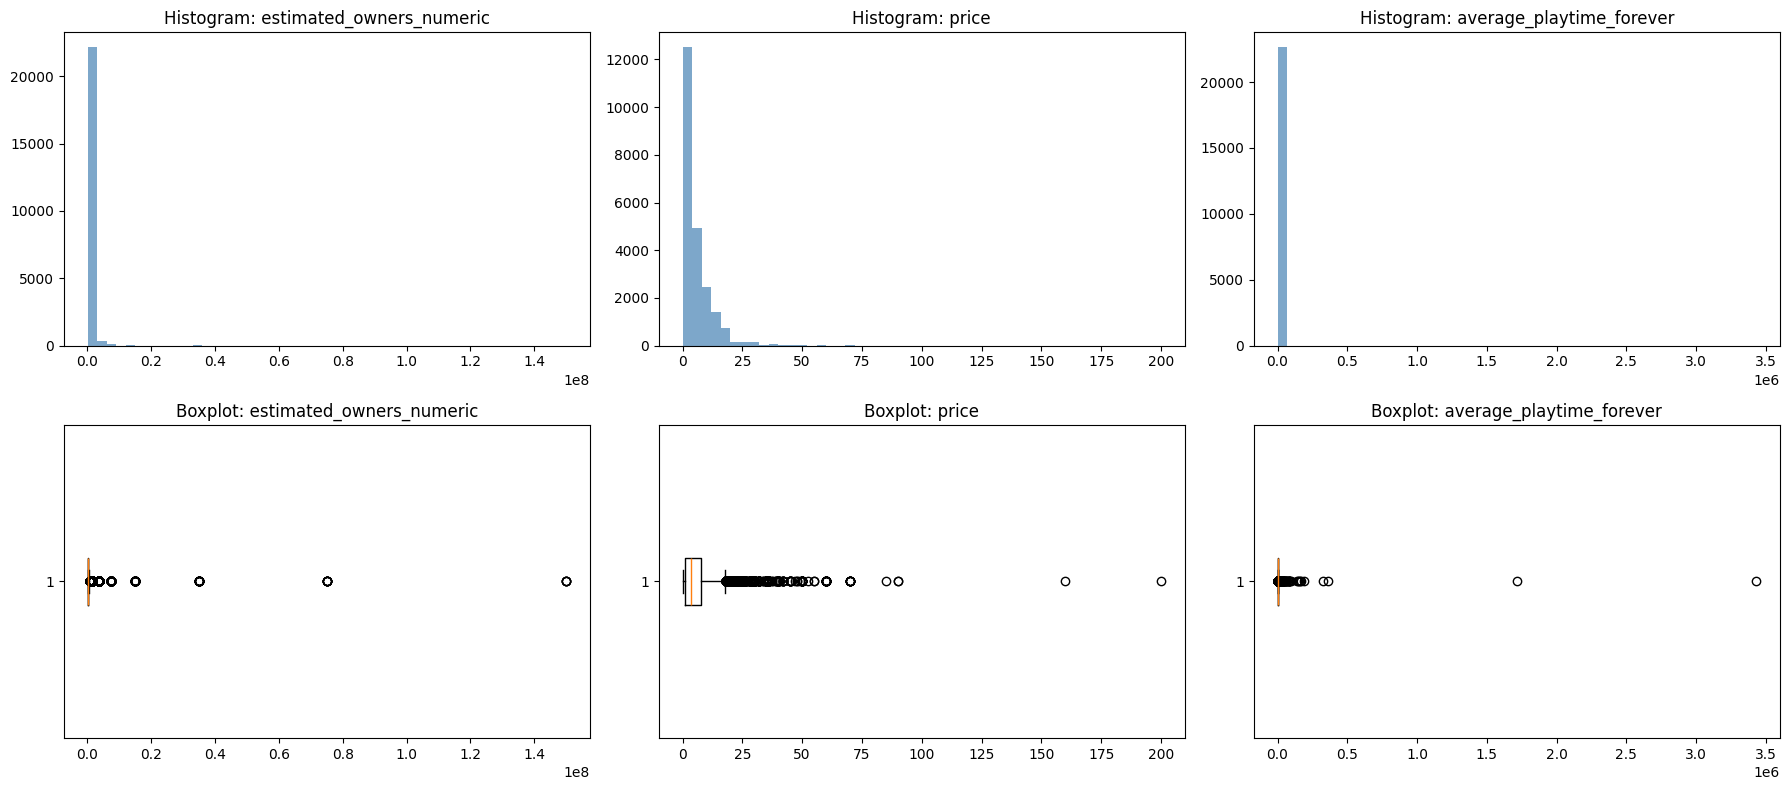

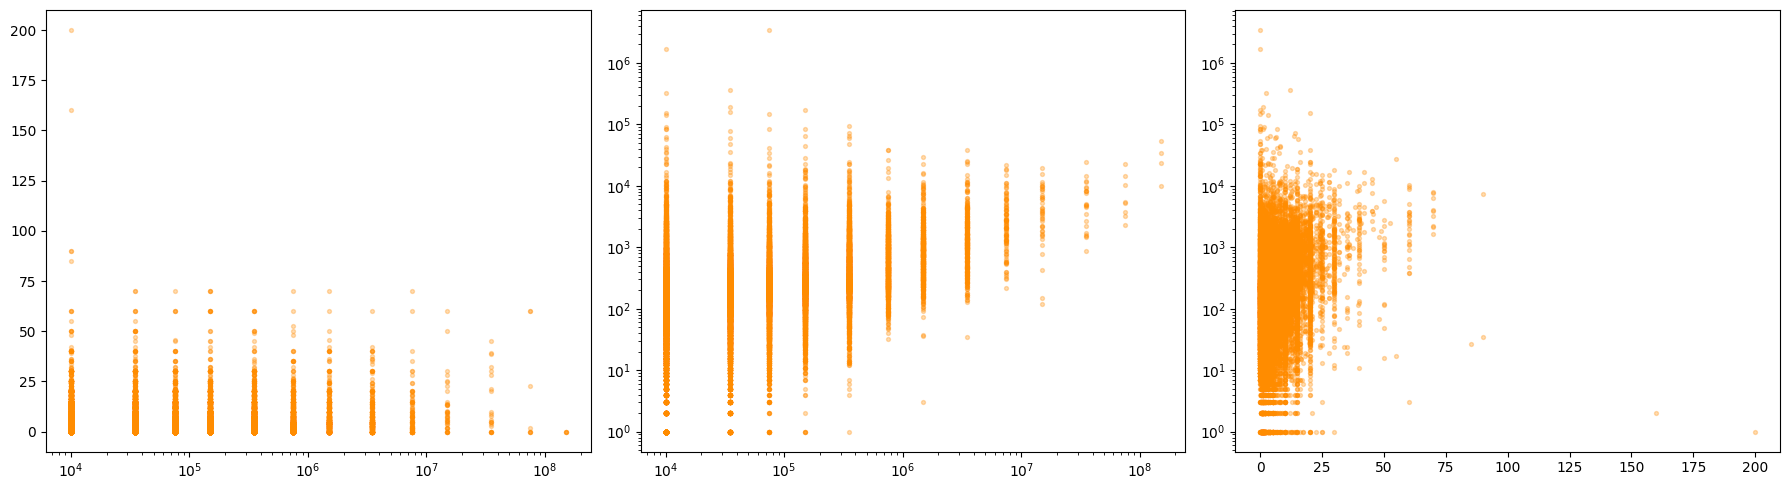

In [ ]:
# P1 — Muat data hasil filtering final
df_final = muat_checkpoint('checkpoints_filtering', '04_filter_level4_final.csv',
                            kolom_list_literal=['genres', 'categories', 'tags'])
FITUR_UTAMA = ['estimated_owners_numeric', 'price', 'average_playtime_forever']
# P2 — Hitung statistik & skewness fitur utama (dipakai lagi di Section H)
stat_utama = df_final[FITUR_UTAMA].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T
skew_awal = pd.DataFrame({
    'skewness': df_final[FITUR_UTAMA].skew(),
    'mean': df_final[FITUR_UTAMA].mean(),
    'median': df_final[FITUR_UTAMA].median(),
}).round(2)
# P3 — Buat & simpan visualisasi distribusi (histogram + boxplot) — FILE PERMANEN
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, kol in enumerate(FITUR_UTAMA):
    axes[0, i].hist(df_final[kol], bins=50, color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'Histogram: {kol}')
    axes[1, i].boxplot(df_final[kol], vert=False)
    axes[1, i].set_title(f'Boxplot: {kol}')
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_G4_distribusi_fitur_utama.png', dpi=150)
# P4 — Hitung korelasi antar 3 fitur utama
matriks_korelasi_utama = df_final[FITUR_UTAMA].corr(method='spearman')
# P5 — Buat & simpan visualisasi scatter plot bivariat — FILE PERMANEN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pasangan = [('estimated_owners_numeric', 'price'),
            ('estimated_owners_numeric', 'average_playtime_forever'),
            ('price', 'average_playtime_forever')]
for i, (fx, fy) in enumerate(pasangan):
    axes[i].scatter(df_final[fx], df_final[fy], alpha=0.3, s=8, color='darkorange')
    if fx == 'estimated_owners_numeric':
        axes[i].set_xscale('log')
    if fy == 'average_playtime_forever':
        axes[i].set_yscale('log')
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_G6_scatter_bivariat.png', dpi=150)
# P6 — Catat bukti proses & log (EDA tidak mengubah jumlah baris, jadi tidak ada checkpoint baru)
simpan_bukti_proses('bukti_G_eda_fitur_utama.csv', {
    'tahap': 'G. EDA Fokus Fitur Utama', 'jumlah_baris': len(df_final),
    'skew_owners_sebelum': round(df_final['estimated_owners_numeric'].skew(), 4),
    'skew_price_sebelum': round(df_final['price'].skew(), 4),
    'skew_playtime_sebelum': round(df_final['average_playtime_forever'].skew(), 4),
    'korelasi_owners_price': round(matriks_korelasi_utama.loc['estimated_owners_numeric', 'price'], 3),
    'korelasi_owners_playtime': round(matriks_korelasi_utama.loc['estimated_owners_numeric', 'average_playtime_forever'], 3),
    'korelasi_price_playtime': round(matriks_korelasi_utama.loc['price', 'average_playtime_forever'], 3),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
tulis_log(tahap='G. EDA Fokus Fitur Utama',
    keterangan='Statistik, distribusi, dan korelasi 3 fitur utama sebelum preprocessing',
    baris_masuk=len(df_final), baris_keluar=len(df_final))

OUTPUT TAMPILAN EDA

In [ ]:
# T1 — Judul section
header("SECTION G — EDA FOKUS 3 FITUR CLUSTERING",
       "Input: 04_filter_level4_final.csv | Fokus: estimated_owners_numeric, price, average_playtime_forever")
# T2 — Info data
section("Status Data")
kv_table({"Sumber": "02_checkpoints_filtering/04_filter_level4_final.csv",
          "Jumlah baris": f"{len(df_final):,}", "Jumlah kolom": df_final.shape[1]})

 SECTION G — EDA FOKUS 3 FITUR CLUSTERING
 Input: 04_filter_level4_final.csv | Fokus: estimated_owners_numeric, price, average_playtime_forever

------------------------------------------------------------------------------
 Status Data
------------------------------------------------------------------------------
+--------------+-----------------------------------------------------+
| Keterangan   | Nilai                                               |
+==============+=====================================================+
| Sumber       | 02_checkpoints_filtering/04_filter_level4_final.csv |
+--------------+-----------------------------------------------------+
| Jumlah baris | 22,659                                              |
+--------------+-----------------------------------------------------+
| Jumlah kolom | 44                                                  |
+--------------+-----------------------------------------------------+


In [ ]:
# T3 — Distribusi genre (konteks deskriptif saja, bukan fitur)
section("G.2 — Konteks Umum Dataset (Genre Dominan)")
semua_genre = df_final['genres'].dropna().explode()
top_genre = semua_genre.value_counts().head(10).reset_index()
top_genre.columns = ['genre', 'jumlah_game']
top_genre['persentase'] = (top_genre['jumlah_game'] / len(df_final) * 100).round(2)
df_table(top_genre, showindex=False)
kv_table({"Catatan": "Genre TIDAK dipakai sebagai fitur clustering — murni konteks deskriptif dataset"})


------------------------------------------------------------------------------
 G.2 — Konteks Umum Dataset (Genre Dominan)
------------------------------------------------------------------------------
+--------------+---------------+--------------+
| genre        |   jumlah_game |   persentase |
+==============+===============+==============+
| Indie        |         15405 |        67.99 |
+--------------+---------------+--------------+
| Action       |          9927 |        43.81 |
+--------------+---------------+--------------+
| Adventure    |          9526 |        42.04 |
+--------------+---------------+--------------+
| Casual       |          7397 |        32.64 |
+--------------+---------------+--------------+
| Simulation   |          5492 |        24.24 |
+--------------+---------------+--------------+
| Strategy     |          5207 |        22.98 |
+--------------+---------------+--------------+
| RPG          |          5061 |        22.34 |
+--------------+-------------

In [ ]:
# T4 — Tampilkan statistik & skewness (hasil dari P2)
section("G.3 — Statistik Deskriptif Fitur Utama (Sebelum Transformasi)")
df_table(stat_utama, floatfmt=",.2f")
section("Skewness Fitur Utama")
df_table(skew_awal)
kv_table({"Interpretasi": "Skewness > 1 atau < -1 = distribusi sangat miring -> dasar transformasi Yeo-Johnson di SECTION H"})


------------------------------------------------------------------------------
 G.3 — Statistik Deskriptif Fitur Utama (Sebelum Transformasi)
------------------------------------------------------------------------------
+--------------------------+-----------+------------+--------------+-----------+-----------+-----------+------------+------------+------------+--------------+----------------+
|                          |     count |       mean |          std |       min |       25% |       50% |        75% |        90% |        95% |          99% |            max |
+==========================+===========+============+==============+===========+===========+===========+============+============+============+==============+================+
| estimated_owners_numeric | 22,659.00 | 343,359.37 | 2,828,667.39 | 10,000.00 | 10,000.00 | 35,000.00 | 150,000.00 | 350,000.00 | 750,000.00 | 3,500,000.00 | 150,000,000.00 |
+--------------------------+-----------+------------+--------------+------

In [ ]:
# T5 — Tampilkan visualisasi distribusi di layar (gambar sudah disimpan di P3)
section("G.4 — Visualisasi Distribusi 3 Fitur Utama")
plt.show()
# T6 — Tampilkan korelasi (hasil dari P4) + tampilkan scatter plot (gambar sudah disimpan di P5)
section("G.5 — Korelasi Antar 3 Fitur Utama (Spearman)")
df_table(matriks_korelasi_utama, floatfmt=".3f")
kv_table({"Interpretasi": "Korelasi |r| < 0.7 antar ketiganya -> tidak ada redundansi berarti"})
section("G.6 — Scatter Plot Bivariat (Pola Sebaran Alami Data)")
plt.show()
# T7 — Penutup section
footer(note="EDA selesai. Lanjut ke SECTION H — Feature Selection & Preprocessing",
       saved_to="viz_G4_distribusi_fitur_utama.png, viz_G6_scatter_bivariat.png, bukti_G_eda_fitur_utama.csv")


------------------------------------------------------------------------------
 G.4 — Visualisasi Distribusi 3 Fitur Utama
------------------------------------------------------------------------------

------------------------------------------------------------------------------
 G.5 — Korelasi Antar 3 Fitur Utama (Spearman)
------------------------------------------------------------------------------
+--------------------------+----------------------------+---------+----------------------------+
|                          |   estimated_owners_numeric |   price |   average_playtime_forever |
+==========================+============================+=========+============================+
| estimated_owners_numeric |                      1.000 |  -0.041 |                      0.398 |
+--------------------------+----------------------------+---------+----------------------------+
| price                    |                     -0.041 |   1.000 |                      0.247 |
+--------

FASE 5 SECTION H - FEATURE SELECTION

In [ ]:
# PROSES LOGIKA FASE 5 SECTION H - FEATURE SELECTION
# P1 — Muat data dari checkpoint filtering final
df_final = muat_checkpoint('checkpoints_filtering', '04_filter_level4_final.csv',
                            kolom_list_literal=['genres', 'categories', 'tags'])
# P2 — Tentukan & ekstrak 3 fitur terpilih untuk clustering
FEATURE_COLS = ['estimated_owners_numeric', 'price', 'average_playtime_forever']
df_features = df_final[FEATURE_COLS].copy()
# P3 — Simpan checkpoint fitur mentah (sebelum transformasi)
path_features_raw = simpan_checkpoint(df_features, 'preprocessing', '05_feature_selection.csv')

OUTPUT TAMPILAN SECTION H - FEATURE SELECTION

In [ ]:
# T1 — Judul section
header("SECTION H — FEATURE SELECTION & PREPROCESSING",
       "Input: 04_filter_level4_final.csv -> Output: 05_feature_selection.csv, 06_feature_scaled.csv")
section("Status Data Masuk")
kv_table({"Sumber": "02_checkpoints_filtering/04_filter_level4_final.csv",
          "Jumlah baris": f"{len(df_final):,}", "Jumlah kolom": df_final.shape[1]})

 SECTION H — FEATURE SELECTION & PREPROCESSING
 Input: 04_filter_level4_final.csv -> Output: 05_feature_selection.csv, 06_feature_scaled.csv

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+-----------------------------------------------------+
| Keterangan   | Nilai                                               |
+==============+=====================================================+
| Sumber       | 02_checkpoints_filtering/04_filter_level4_final.csv |
+--------------+-----------------------------------------------------+
| Jumlah baris | 22,659                                              |
+--------------+-----------------------------------------------------+
| Jumlah kolom | 44                                                  |
+--------------+-----------------------------------------------------+


In [ ]:
# T2 — Justifikasi pemilihan fitur
section("H.2 — Fitur Terpilih untuk Clustering")
kv_table({
    "estimated_owners_numeric": "Merepresentasikan skala popularitas/jangkauan pemain",
    "price": "Merepresentasikan posisi harga/model bisnis game",
    "average_playtime_forever": "Merepresentasikan tingkat keterlibatan (engagement) pemain",
    "Dasar pemilihan": "3 dimensi independen, tervalidasi tidak redundan pada SECTION G (korelasi |r| < 0.7)",})


------------------------------------------------------------------------------
 H.2 — Fitur Terpilih untuk Clustering
------------------------------------------------------------------------------
+--------------------------+--------------------------------------------------------------------------------------+
| Keterangan               | Nilai                                                                                |
+==========================+======================================================================================+
| estimated_owners_numeric | Merepresentasikan skala popularitas/jangkauan pemain                                 |
+--------------------------+--------------------------------------------------------------------------------------+
| price                    | Merepresentasikan posisi harga/model bisnis game                                     |
+--------------------------+------------------------------------------------------------------------------

In [ ]:

# T3 — Statistik skewness sebelum transformasi (ringkasan, bukan olahan baru)
section("H.3 — Konfirmasi Skewness Sebelum Transformasi")
stat_rows = [[c, f"{df_features[c].isnull().sum()}", f"{df_features[c].skew():.4f}",
              f"{df_features[c].mean():,.2f}", f"{df_features[c].median():,.2f}"] for c in FEATURE_COLS]
print(tabulate(stat_rows, headers=["Fitur", "Missing", "Skewness", "Mean", "Median"], tablefmt="grid"))


------------------------------------------------------------------------------
 H.3 — Konfirmasi Skewness Sebelum Transformasi
------------------------------------------------------------------------------
+--------------------------+-----------+------------+------------+-----------+
| Fitur                    |   Missing |   Skewness | Mean       | Median    |
+==========================+===========+============+============+===========+
| estimated_owners_numeric |         0 |    34.8468 | 343,359.37 | 35,000.00 |
+--------------------------+-----------+------------+------------+-----------+
| price                    |         0 |     4.2588 | 5.66       | 3.74      |
+--------------------------+-----------+------------+------------+-----------+
| average_playtime_forever |         0 |   115.122  | 913.40     | 216.00    |
+--------------------------+-----------+------------+------------+-----------+


FASE 5 SECTION  - PREPROCESSING

In [ ]:
# PROSES LOGIKA PREPROCESSING
# P1 — Transformasi Yeo-Johnson (menormalkan distribusi skewed)
from sklearn.preprocessing import PowerTransformer, StandardScaler
pt = PowerTransformer(method='yeo-johnson', standardize=False)
X_transformed = pt.fit_transform(df_features[FEATURE_COLS])
df_transformed = pd.DataFrame(X_transformed, columns=FEATURE_COLS, index=df_features.index)
# P2 — Scaling standar (menyamakan skala antar fitur)
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(df_transformed)
df_scaled = pd.DataFrame(X_scaled_arr, columns=FEATURE_COLS, index=df_features.index)
# P3 — Simpan checkpoint data hasil scaling
path_scaled = simpan_checkpoint(df_scaled, 'preprocessing', '06_feature_scaled.csv')
# P4 — Simpan model transformasi (untuk dipakai ulang/inverse transform nanti)
joblib.dump(pt, FOLDERS['model'] + 'power_transformer.pkl')
joblib.dump(scaler, FOLDERS['model'] + 'standard_scaler.pkl')
# P5 — Catat bukti proses
simpan_bukti_proses('bukti_H_preprocessing.csv', {
    'tahap': 'H. Feature Selection & Preprocessing', 'fitur_terpilih': ', '.join(FEATURE_COLS),
    'metode_transformasi': 'Yeo-Johnson PowerTransformer + StandardScaler',
    'skewness_owners_sebelum': round(df_features['estimated_owners_numeric'].skew(), 4),
    'skewness_owners_sesudah': round(df_transformed['estimated_owners_numeric'].skew(), 4),
    'skewness_price_sebelum': round(df_features['price'].skew(), 4),
    'skewness_price_sesudah': round(df_transformed['price'].skew(), 4),
    'skewness_playtime_sebelum': round(df_features['average_playtime_forever'].skew(), 4),
    'skewness_playtime_sesudah': round(df_transformed['average_playtime_forever'].skew(), 4),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
# P6 — Catat manifest & log
tulis_manifest(tahap='H-a. Feature Selection', nama_file='05_feature_selection.csv',
    path_file=path_features_raw, df=df_features, deskripsi='Tiga fitur mentah terpilih untuk clustering')
tulis_manifest(tahap='H-b. Feature Scaled', nama_file='06_feature_scaled.csv',
    path_file=path_scaled, df=df_scaled, deskripsi='Fitur setelah Yeo-Johnson + StandardScaler')
tulis_log(tahap='H. Feature Selection & Preprocessing',
    keterangan='Yeo-Johnson + StandardScaler pada 3 fitur terpilih',
    baris_masuk=len(df_final), baris_keluar=len(df_scaled))

OUTPUT TAMPILAN PREPROCESSING

In [ ]:
# T1 — Judul sub-bagian
section("H.4 — Transformasi Yeo-Johnson + StandardScaler")
# T2 — Tampilkan hasil transformasi (bukti skewness membaik)
result_rows = [[c, f"{df_transformed[c].skew():.4f}", f"{df_scaled[c].mean():.2e}", f"{df_scaled[c].std():.4f}"]
               for c in FEATURE_COLS]
print(tabulate(result_rows, headers=["Fitur", "Skewness Setelah YJ", "Mean Scaled (~0)", "Std Scaled (~1)"], tablefmt="grid"))
section("Contoh 10 Baris Data Setelah Scaling")
df_table(df_scaled.head(10))
# T3 — Penutup section
footer(note="Model (power_transformer.pkl, standard_scaler.pkl) tersimpan di 04_model/. "
            "Lanjut ke SECTION I — Penentuan K Optimal",
       saved_to=f"{path_features_raw}, {path_scaled}")


------------------------------------------------------------------------------
 H.4 — Transformasi Yeo-Johnson + StandardScaler
------------------------------------------------------------------------------
+--------------------------+-----------------------+--------------------+-------------------+
| Fitur                    |   Skewness Setelah YJ |   Mean Scaled (~0) |   Std Scaled (~1) |
+==========================+=======================+====================+===================+
| estimated_owners_numeric |                0.1256 |           3.69e-15 |                 1 |
+--------------------------+-----------------------+--------------------+-------------------+
| price                    |                0.0096 |           4.14e-17 |                 1 |
+--------------------------+-----------------------+--------------------+-------------------+
| average_playtime_forever |                0.0315 |          -1.81e-16 |                 1 |
+--------------------------+------------

FASE 6 SECTION I - PENENTUAN K OPRIMAL

In [ ]:
# PROSES LOGIKA PENENTUAN K OPRIMAL
# P1 — Muat data scaled dari checkpoint
df_scaled = muat_checkpoint('preprocessing', '06_feature_scaled.csv')
X_scaled = df_scaled.values
# P2 — Evaluasi K=2 sampai 10 (loop inti: fit KMeans, hitung 3 metrik)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
K_range = range(2, 11)
hasil_k = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    hasil_k.append({
        'K': k, 'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
    })
ringkasan_k = pd.DataFrame(hasil_k)
# P3 — Identifikasi K terbaik berdasarkan Silhouette & DBI
k_terbaik_silhouette = ringkasan_k.loc[ringkasan_k['Silhouette'].idxmax(), 'K']
k_terbaik_dbi = ringkasan_k.loc[ringkasan_k['Davies-Bouldin'].idxmin(), 'K']
# P4 — Simpan checkpoint tabel evaluasi
path_evaluasi_k = FOLDERS['clustering'] + '07_evaluasi_k_optimal.csv'
ringkasan_k.to_csv(path_evaluasi_k, index=False)
# P5 — Catat bukti proses
simpan_bukti_proses('bukti_I_evaluasi_k.csv', {
    'tahap': 'I. Penentuan K Optimal', 'rentang_k_diuji': f"{K_range.start}-{K_range.stop-1}",
    'k_terbaik_silhouette': int(k_terbaik_silhouette),
    'nilai_silhouette_terbaik': round(ringkasan_k['Silhouette'].max(), 4),
    'k_terbaik_dbi': int(k_terbaik_dbi),
    'nilai_dbi_terbaik': round(ringkasan_k['Davies-Bouldin'].min(), 4),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
# P7 — Catat manifest
tulis_manifest(tahap='I. Penentuan K Optimal', nama_file='07_evaluasi_k_optimal.csv',
    path_file=path_evaluasi_k, df=ringkasan_k,
    deskripsi='Tabel evaluasi K=2 s/d 10: Inertia, Silhouette Score, Davies-Bouldin Index')
# P8 — Catat log
tulis_log(tahap='I. Penentuan K Optimal',
    keterangan=f'Evaluasi K=2-10, rekomendasi K={int(k_terbaik_silhouette)} berdasarkan Silhouette tertinggi',
    baris_masuk=len(df_scaled), baris_keluar=len(df_scaled))

OUTPUT TAMPILAN PENENTUAN K OPRIMAL

In [ ]:
# T1 — Judul section
header("SECTION I — PENENTUAN K OPTIMAL",
       "Input: 06_feature_scaled.csv -> Output: 07_evaluasi_k_optimal.csv "
       "| Metode: Elbow, Silhouette Score, Davies-Bouldin Index")
# T2 — Info data masuk
section("Status Data Masuk")
kv_table({"Sumber": "03_preprocessing/06_feature_scaled.csv",
          "Jumlah baris": f"{len(df_scaled):,}", "Jumlah kolom": df_scaled.shape[1]})
# T3 — Tampilkan tabel hasil evaluasi (hasil dari P2)
section("I.2 — Evaluasi K = 2 s/d 10")
df_table(ringkasan_k, floatfmt=".4f", showindex=False)

 SECTION I — PENENTUAN K OPTIMAL
 Input: 06_feature_scaled.csv -> Output: 07_evaluasi_k_optimal.csv | Metode: Elbow, Silhouette Score, Davies-Bouldin Index

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+--------------+----------------------------------------+
| Keterangan   | Nilai                                  |
+==============+========================================+
| Sumber       | 03_preprocessing/06_feature_scaled.csv |
+--------------+----------------------------------------+
| Jumlah baris | 22,659                                 |
+--------------+----------------------------------------+
| Jumlah kolom | 3                                      |
+--------------+----------------------------------------+

------------------------------------------------------------------------------
 I.2 — Evaluasi K = 2 s/d 10
-----------------------------------


------------------------------------------------------------------------------
 I.3 — Visualisasi Elbow, Silhouette, Davies-Bouldin
------------------------------------------------------------------------------


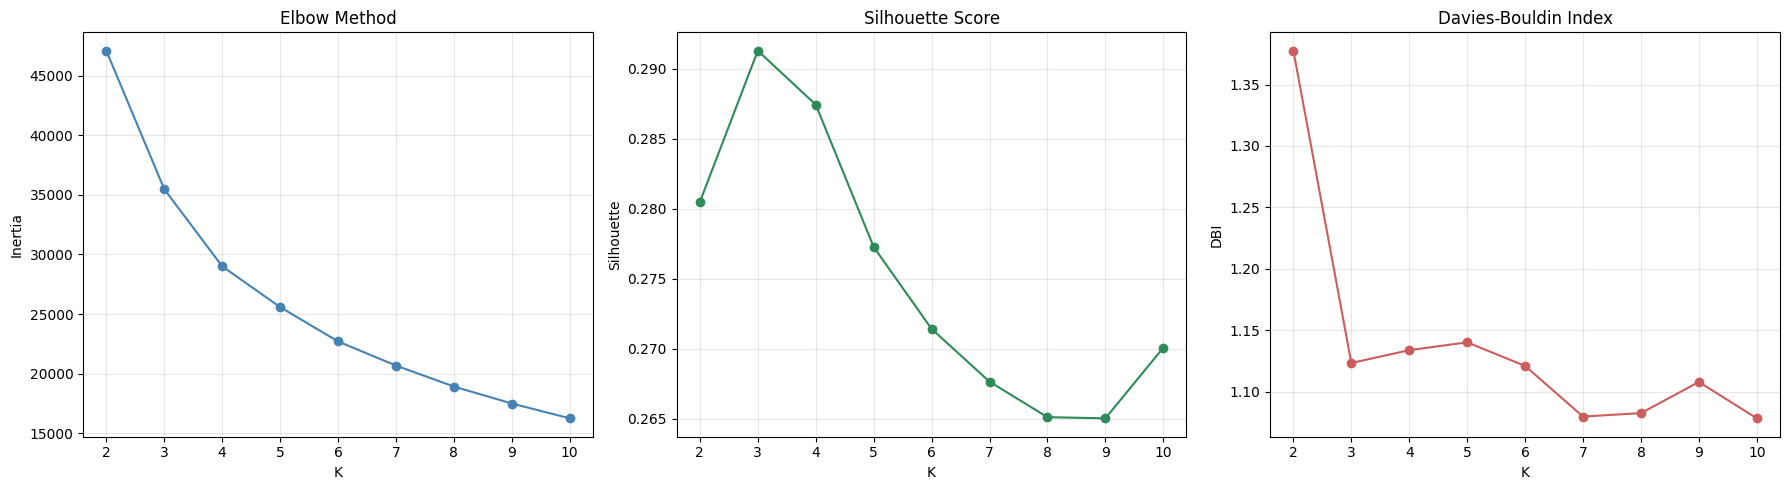


------------------------------------------------------------------------------
 I.4 — Rekomendasi K Optimal
------------------------------------------------------------------------------
+----------------------------------+-----------------------------+
| Keterangan                       | Nilai                       |
+==================================+=============================+
| K dengan Silhouette tertinggi    | K = 3 (Silhouette = 0.2913) |
+----------------------------------+-----------------------------+
| K dengan Davies-Bouldin terendah | K = 10 (DBI = 1.0783)       |
+----------------------------------+-----------------------------+
------------------------------------------------------------------------------
 Output disimpan : /content/drive/MyDrive/skripsi_steam/05_clustering/07_evaluasi_k_optimal.csv
 Catatan         : K optimal yang direkomendasikan: K = 3. Lanjut ke SECTION J — Fitting K-Means vs K-Medoids
 Waktu eksekusi  : 2026-08-10 06:06:06



In [ ]:
# T4 — Tampilkan visualisasi (gambar sudah disimpan di P3)
# Buat & simpan visualisasi 3 metrik — FILE PERMANEN
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, ringkasan_k['Inertia'], marker='o', color='steelblue')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, ringkasan_k['Silhouette'], marker='o', color='seagreen')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
axes[2].plot(K_range, ringkasan_k['Davies-Bouldin'], marker='o', color='indianred')
axes[2].set_title('Davies-Bouldin Index'); axes[2].set_xlabel('K'); axes[2].set_ylabel('DBI')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_I3_evaluasi_K_optimal.png', dpi=150)
section("I.3 — Visualisasi Elbow, Silhouette, Davies-Bouldin")
plt.show()
# T5 — Tampilkan rekomendasi K terbaik (hasil dari P4)
section("I.4 — Rekomendasi K Optimal")
kv_table({
    "K dengan Silhouette tertinggi": f"K = {int(k_terbaik_silhouette)} (Silhouette = {ringkasan_k['Silhouette'].max():.4f})",
    "K dengan Davies-Bouldin terendah": f"K = {int(k_terbaik_dbi)} (DBI = {ringkasan_k['Davies-Bouldin'].min():.4f})",})
# T6 — Penutup section
footer(note=f"K optimal yang direkomendasikan: K = {int(k_terbaik_silhouette)}. "
             "Lanjut ke SECTION J — Fitting K-Means vs K-Medoids",
       saved_to=path_evaluasi_k)

FASE 7 SECTION J - PERSIAPAN DATA DAN VALIDASI INDEX

In [ ]:
# PROSES LOGIKA PERSIAPAN DATA DAN VALIDASI INDEX
# P1 — Install & import library, muat dataset
!pip install -q kmedoids
from sklearn.metrics import pairwise_distances
import kmedoids
df_scaled = muat_checkpoint('preprocessing', '06_feature_scaled.csv')
df_final  = muat_checkpoint('checkpoints_filtering', '04_filter_level4_final.csv',
                             kolom_list_literal=['genres', 'categories', 'tags'])
# P2 — Cek & selaraskan index (AppID) — WAJIB sebelum fitting model manapun
index_sama_persis = df_scaled.index.equals(df_final.index)
appid_hanya_di_scaled = set(df_scaled.index) - set(df_final.index)
appid_hanya_di_final = set(df_final.index) - set(df_scaled.index)
df_final_aligned = df_final.loc[df_scaled.index]
assert df_final_aligned.index.equals(df_scaled.index), \
    "GAGAL: penyelarasan index tidak berhasil, hentikan proses untuk cek manual"
# P3 — Siapkan variabel yang dipakai di kedua model
X_scaled = df_scaled.values
K_FINAL = 3
RANDOM_STATE = 42

OUTPUT

In [ ]:
header("SECTION J — FITTING K-MEANS vs K-MEDOIDS",
       "Input: 06_feature_scaled.csv, 04_filter_level4_final.csv | K = 3 | random_state = 42")
section("Status Data Masuk")
kv_table({"Sumber fitur scaled": "03_preprocessing/06_feature_scaled.csv",
          "Sumber data final": "02_checkpoints_filtering/04_filter_level4_final.csv",
          "Jumlah baris (scaled)": f"{len(df_scaled):,}", "Jumlah baris (final)": f"{len(df_final):,}"})
section("J.2b — Validasi Keselarasan Index (AppID)")
kv_table({
    "Index (AppID) identik & urutan sama": "YA" if index_sama_persis else "TIDAK — perlu penyelarasan",
    "AppID hanya ada di df_scaled": f"{len(appid_hanya_di_scaled):,}",
    "AppID hanya ada di df_final": f"{len(appid_hanya_di_final):,}",})
print("Index df_final berhasil diselaraskan mengikuti df_scaled berdasarkan AppID.")

 SECTION J — FITTING K-MEANS vs K-MEDOIDS
 Input: 06_feature_scaled.csv, 04_filter_level4_final.csv | K = 3 | random_state = 42

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+-----------------------+-----------------------------------------------------+
| Keterangan            | Nilai                                               |
+=======================+=====================================================+
| Sumber fitur scaled   | 03_preprocessing/06_feature_scaled.csv              |
+-----------------------+-----------------------------------------------------+
| Sumber data final     | 02_checkpoints_filtering/04_filter_level4_final.csv |
+-----------------------+-----------------------------------------------------+
| Jumlah baris (scaled) | 22,659                                              |
+-----------------------+-----------------------------

FASE 8 SECTION J - FITTING K-MEANS

In [ ]:
# P1 — Fit K-Means
kmeans_model = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=10, random_state=RANDOM_STATE)
labels_kmeans = kmeans_model.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
dbi_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
vc_km = pd.Series(labels_kmeans).value_counts().sort_index()

OUTPUT TAMPILAN FITTING K-MEANS

In [ ]:
section("J.3 — Fitting K-Means")
kv_table({
    "Jumlah cluster (K)": K_FINAL,
    "Silhouette Score": f"{sil_kmeans:.4f}",
    "Davies-Bouldin Index": f"{dbi_kmeans:.4f}",
})


------------------------------------------------------------------------------
 J.3 — Fitting K-Means
------------------------------------------------------------------------------
+----------------------+---------+
| Keterangan           |   Nilai |
+======================+=========+
| Jumlah cluster (K)   |  3      |
+----------------------+---------+
| Silhouette Score     |  0.2913 |
+----------------------+---------+
| Davies-Bouldin Index |  1.1234 |
+----------------------+---------+


FASE 8 SECTION J FITTING K MEDOIDS

In [ ]:
# P1 — Fit K-Medoids
dist_matrix = pairwise_distances(X_scaled, metric='euclidean')
km_result = kmedoids.fasterpam(dist_matrix, K_FINAL, random_state=RANDOM_STATE)
labels_kmedoids = km_result.labels
sil_kmedoids = silhouette_score(X_scaled, labels_kmedoids)
dbi_kmedoids = davies_bouldin_score(X_scaled, labels_kmedoids)
vc_kmd = pd.Series(labels_kmedoids).value_counts().sort_index()

OUTPUT TAMPILAN FITTING K-MEDOIDS

In [ ]:
section("J.4 — Fitting K-Medoids (FasterPAM)")
kv_table({
    "Jumlah cluster (K)": K_FINAL,
    "Silhouette Score": f"{sil_kmedoids:.4f}",
    "Davies-Bouldin Index": f"{dbi_kmedoids:.4f}",
})


------------------------------------------------------------------------------
 J.4 — Fitting K-Medoids (FasterPAM)
------------------------------------------------------------------------------
+----------------------+---------+
| Keterangan           |   Nilai |
+======================+=========+
| Jumlah cluster (K)   |  3      |
+----------------------+---------+
| Silhouette Score     |  0.2922 |
+----------------------+---------+
| Davies-Bouldin Index |  1.1493 |
+----------------------+---------+


FASE 8 SECTION J - PENGGABUNGAN DAN PERBANDINGAN

In [ ]:
# P1 — Gabungkan kedua label ke dataset final (butuh hasil Blok 2 & 3)
df_result = df_final_aligned.copy()
df_result['cluster_kmeans']   = pd.Series(labels_kmeans, index=df_scaled.index)
df_result['cluster_kmedoids'] = pd.Series(labels_kmedoids, index=df_scaled.index)
assert df_result['cluster_kmeans'].notna().all() and df_result['cluster_kmedoids'].notna().all(), \
    "GAGAL: ada baris tanpa label cluster — index tidak selaras sempurna"
# P2 — Simpan checkpoint hasil gabungan
path_hasil_fitting = simpan_checkpoint(df_result, 'clustering', '08_hasil_kmeans_vs_kmedoids.csv')
# P3 — Catat bukti proses
simpan_bukti_proses('bukti_J_fitting_kmeans_kmedoids.csv', {
    'tahap': 'J. Fitting K-Means vs K-Medoids', 'K': K_FINAL, 'random_state': RANDOM_STATE,
    'silhouette_kmeans': round(sil_kmeans, 4), 'dbi_kmeans': round(dbi_kmeans, 4),
    'silhouette_kmedoids': round(sil_kmedoids, 4), 'dbi_kmedoids': round(dbi_kmedoids, 4),
    'distribusi_kmeans': dict(vc_km), 'distribusi_kmedoids': dict(vc_kmd),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
# P4 — Catat manifest & log
tulis_manifest(tahap='J. Fitting K-Means vs K-Medoids', nama_file='08_hasil_kmeans_vs_kmedoids.csv',
    path_file=path_hasil_fitting, df=df_result,
    deskripsi=f'Hasil fitting K-Means dan K-Medoids (K={K_FINAL}), label digabung eksplisit berdasarkan AppID')
tulis_log(tahap='J. Fitting K-Means vs K-Medoids',
    keterangan=f'Fitting K={K_FINAL} dengan validasi index AppID eksplisit',
    baris_masuk=len(df_final), baris_keluar=len(df_result))

OUTPUT TAMPILAN PENGGABUNGAN DAN PERBANDINGAN

In [ ]:
section("J.5 — Penggabungan Label (Eksplisit Berdasarkan AppID)")
kv_table({
    "Baris dengan cluster_kmeans terisi": f"{df_result['cluster_kmeans'].notna().sum():,} / {len(df_result):,}",
    "Baris dengan cluster_kmedoids terisi": f"{df_result['cluster_kmedoids'].notna().sum():,} / {len(df_result):,}",})
section("J.6 — Distribusi Anggota Cluster")
dist_rows = [[c, vc_km.get(c, 0), vc_kmd.get(c, 0)] for c in sorted(set(vc_km.index) | set(vc_kmd.index))]
print(tabulate(dist_rows, headers=["Cluster", "K-Means", "K-Medoids"], tablefmt="grid"))
section("J.7 — Perbandingan Metrik Evaluasi")
metric_rows = [["K-Means", f"{sil_kmeans:.4f}", f"{dbi_kmeans:.4f}"],
               ["K-Medoids", f"{sil_kmedoids:.4f}", f"{dbi_kmedoids:.4f}"]]
print(tabulate(metric_rows, headers=["Model", "Silhouette Score", "Davies-Bouldin Index"], tablefmt="grid"))
footer(note="Kedua model dievaluasi berdampingan. Keputusan model utama di SECTION K.",
       saved_to=path_hasil_fitting)


------------------------------------------------------------------------------
 J.5 — Penggabungan Label (Eksplisit Berdasarkan AppID)
------------------------------------------------------------------------------
+--------------------------------------+-----------------+
| Keterangan                           | Nilai           |
+======================================+=================+
| Baris dengan cluster_kmeans terisi   | 22,659 / 22,659 |
+--------------------------------------+-----------------+
| Baris dengan cluster_kmedoids terisi | 22,659 / 22,659 |
+--------------------------------------+-----------------+

------------------------------------------------------------------------------
 J.6 — Distribusi Anggota Cluster
------------------------------------------------------------------------------
+-----------+-----------+-------------+
|   Cluster |   K-Means |   K-Medoids |
+===========+===========+=============+
|         0 |      6864 |        7179 |
+-----------+------

FASE 9 SECTION K - PROFILLING Z SCORE PER CLASTER

In [ ]:
# P1 — Muat dataset hasil fitting & dataset scaled
df_result = muat_checkpoint('clustering', '08_hasil_kmeans_vs_kmedoids.csv',
                             kolom_list_literal=['genres', 'categories', 'tags'])
df_scaled = muat_checkpoint('preprocessing', '06_feature_scaled.csv')
FEATURE_COLS = ['estimated_owners_numeric', 'price', 'average_playtime_forever']
THRESHOLD = 0.5
# P2 — Validasi & selaraskan index (AppID) sebelum menggabungkan z-score
index_sama = df_result.index.equals(df_scaled.index)
if not index_sama:
    df_scaled = df_scaled.loc[df_result.index]
    assert df_scaled.index.equals(df_result.index), "GAGAL: penyelarasan index tidak berhasil"
# P3 — Gabungkan kolom z-score ke df_result
for kol in FEATURE_COLS:
    df_result[f'{kol}_z'] = df_scaled[kol].values
# P4 — Hitung profil rata-rata z-score per cluster
KOLOM_Z = [f'{k}_z' for k in FEATURE_COLS]
ringkasan_zscore = df_result.groupby('cluster_kmedoids')[KOLOM_Z].mean()
ringkasan_zscore.columns = FEATURE_COLS

OUTPUT TAMPILAN  PROFILLING Z SCORE PER CLASTER

In [ ]:
header("SECTION K — PROFILING & LABELING CLUSTER (Z-SCORE)",
       "Input: 08_hasil_kmeans_vs_kmedoids.csv, 06_feature_scaled.csv | Model utama: K-Medoids | Threshold |z| >= 0.5")
section("Status Data Masuk")
kv_table({"Sumber cluster": "05_clustering/08_hasil_kmeans_vs_kmedoids.csv",
          "Sumber scaled": "03_preprocessing/06_feature_scaled.csv", "Jumlah baris": f"{len(df_result):,}"})
section("K.1b — Validasi Keselarasan Index (AppID)")
kv_table({"Index df_result & df_scaled identik": "YA" if index_sama else "TIDAK — perlu penyelarasan"})
if not index_sama:
    print("Index df_scaled berhasil diselaraskan mengikuti df_result.")
section("K.2 — Profil Rata-rata Z-Score per Cluster (K-Medoids)")
df_table(ringkasan_zscore.round(3))
kv_table({"Interpretasi": f"Rata-rata z-score cluster relatif terhadap seluruh populasi ({len(df_result):,} game). "
                          f"Threshold |z| >= {THRESHOLD} = ambang 'efek sedang' (mirip konvensi Cohen's d)."})

 SECTION K — PROFILING & LABELING CLUSTER (Z-SCORE)
 Input: 08_hasil_kmeans_vs_kmedoids.csv, 06_feature_scaled.csv | Model utama: K-Medoids | Threshold |z| >= 0.5

------------------------------------------------------------------------------
 Status Data Masuk
------------------------------------------------------------------------------
+----------------+-----------------------------------------------+
| Keterangan     | Nilai                                         |
+================+===============================================+
| Sumber cluster | 05_clustering/08_hasil_kmeans_vs_kmedoids.csv |
+----------------+-----------------------------------------------+
| Sumber scaled  | 03_preprocessing/06_feature_scaled.csv        |
+----------------+-----------------------------------------------+
| Jumlah baris   | 22,659                                        |
+----------------+-----------------------------------------------+

-------------------------------------------------------

FASE 9 SECTION K - VALIDASI STATISTIK KRUSKAL WILLS

In [ ]:
# P1 — Uji Kruskal-Wallis tiap fitur antar cluster (skala asli, bukan z-score)
from scipy.stats import kruskal
hasil_uji = []
for kol in FEATURE_COLS:
    grup = [df_result[df_result['cluster_kmedoids'] == cid][kol]
            for cid in sorted(df_result['cluster_kmedoids'].unique())]
    stat, p_value = kruskal(*grup)
    hasil_uji.append({'fitur': kol, 'H_statistic': round(stat, 4), 'p_value': p_value,
                       'signifikan': 'YA (p < 0.05)' if p_value < 0.05 else 'TIDAK'})
df_uji_statistik = pd.DataFrame(hasil_uji)

OUTPUT TAMPILAN VALIDASI STATISTIK KRUSKAL WILLS

In [ ]:
section("K.3 — Uji Kruskal-Wallis Antar Cluster (per Fitur, skala asli)")
df_table(df_uji_statistik, floatfmt=".4g", showindex=False)


------------------------------------------------------------------------------
 K.3 — Uji Kruskal-Wallis Antar Cluster (per Fitur, skala asli)
------------------------------------------------------------------------------
+--------------------------+---------------+-----------+---------------+
| fitur                    |   H_statistic |   p_value | signifikan    |
+==========================+===============+===========+===============+
| estimated_owners_numeric |     1.424e+04 |         0 | YA (p < 0.05) |
+--------------------------+---------------+-----------+---------------+
| price                    |     1.233e+04 |         0 | YA (p < 0.05) |
+--------------------------+---------------+-----------+---------------+
| average_playtime_forever |  6469         |         0 | YA (p < 0.05) |
+--------------------------+---------------+-----------+---------------+


FASE 9 SECTION K - LOGIKA PELABELAN MULTI DIMENSI

In [ ]:
# P1 — Fungsi klasifikasi 1 dimensi berdasarkan threshold z-score
def klasifikasi_dimensi(z_value, label_tinggi, label_rendah, threshold=THRESHOLD):
    if z_value >= threshold:
        return label_tinggi
    elif z_value <= -threshold:
        return label_rendah
    else:
        return None
# P2 — Fungsi gabungan 3 dimensi jadi satu label deskriptif
def buat_label_cluster(row):
    status_popularitas = klasifikasi_dimensi(row['estimated_owners_numeric'], "Populer", "Niche")
    status_harga       = klasifikasi_dimensi(row['price'], "Premium", "Budget/F2P")
    status_engagement  = klasifikasi_dimensi(row['average_playtime_forever'], "Engagement Tinggi", "Engagement Rendah")
    komponen = [s for s in [status_popularitas, status_harga, status_engagement] if s is not None]
    return "Netral/Seimbang" if len(komponen) == 0 else " - ".join(komponen)
# P3 — Terapkan fungsi ke tiap cluster, hasilkan pemetaan label
label_cluster = {}
detail_dimensi = {}
for cid in ringkasan_zscore.index:
    row = ringkasan_zscore.loc[cid]
    label_cluster[cid] = buat_label_cluster(row)
    detail_dimensi[cid] = {
        'estimated_owners_numeric_z': round(row['estimated_owners_numeric'], 3),
        'price_z': round(row['price'], 3),
        'average_playtime_forever_z': round(row['average_playtime_forever'], 3),}
# P4 — Terapkan label ke seluruh dataset + validasi keras
df_result['cluster_final'] = df_result['cluster_kmedoids']
df_result['label_cluster'] = df_result['cluster_final'].map(label_cluster)
assert df_result['label_cluster'].notna().all(), "GAGAL: ada baris tanpa label -- cek pemetaan cluster_final"

OUTPUT TAMPILAN LOGIKA PELABELAN MULTI DIMENSI

In [ ]:
section("K.4 — Logika Pelabelan (Threshold Z-Score, Multi-Dimensi)")
kv_table({
    "Dimensi 1 - Popularitas": f"z >= +{THRESHOLD} -> Populer | z <= -{THRESHOLD} -> Niche | selain itu -> Menengah",
    "Dimensi 2 - Harga": f"z >= +{THRESHOLD} -> Premium | z <= -{THRESHOLD} -> Budget/F2P | selain itu -> Menengah",
    "Dimensi 3 - Keterlibatan": f"z >= +{THRESHOLD} -> Engagement Tinggi | z <= -{THRESHOLD} -> Engagement Rendah | selain itu -> Menengah",
    "Catatan": "Kombinasi dimensi yang menonjol (|z| >= threshold). Interpretasi kualitatif berbasis "
               "aturan bisnis terhadap hasil cluster kuantitatif, bukan taksonomi murni statistik.",})
section("K.4b — Detail Klasifikasi Dimensi per Cluster")
df_detail = pd.DataFrame(detail_dimensi).T
df_detail['label_final'] = df_detail.index.map(label_cluster)
df_table(df_detail, floatfmt=".3f")
section("K.5 — Distribusi Jumlah Game per Label")
distribusi_label = df_result[['cluster_final', 'label_cluster']].value_counts().reset_index(name='jumlah_game')
distribusi_label['persentase'] = (distribusi_label['jumlah_game'] / len(df_result) * 100).round(2)
df_table(distribusi_label, showindex=False)


------------------------------------------------------------------------------
 K.4 — Logika Pelabelan (Threshold Z-Score, Multi-Dimensi)
------------------------------------------------------------------------------
+--------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Keterangan               | Nilai                                                                                                                                                                   |
+==========================+=========================================================================================================================================================================+
| Dimensi 1 - Popularitas  | z >= +0.5 -> Populer | z <= -0.5 -> Niche | selain itu -> Menengah                                                                                          

FASE 9 SECTION K - SANITY CHECK

In [ ]:
# P1 — Bersihkan kolom bantu z-score sebelum disimpan
df_result_simpan = df_result.drop(columns=KOLOM_Z)
# P2 — Simpan checkpoint final
path_final_labeled = simpan_checkpoint(df_result_simpan, 'clustering', '09_clustered_labeled_final.csv')
# P3 — Catat bukti proses
simpan_bukti_proses('bukti_K_profiling_labeling.csv', {
    'tahap': 'K. Profiling & Labeling (Z-Score)', 'model_utama': 'K-Medoids', 'threshold_zscore': THRESHOLD,
    'pemetaan_label': dict(label_cluster), 'profil_zscore': ringkasan_zscore.round(3).to_dict(),
    'uji_kruskal_wallis': {row['fitur']: {'H': row['H_statistic'], 'p_value': row['p_value']} for row in hasil_uji},
    'distribusi_final': dict(zip(distribusi_label['label_cluster'], distribusi_label['jumlah_game'])),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
# P4 — Catat manifest & log
tulis_manifest(tahap='K. Profiling & Labeling', nama_file='09_clustered_labeled_final.csv',
    path_file=path_final_labeled, df=df_result_simpan,
    deskripsi=f'Dataset final dengan label segmen berbasis threshold z-score (|z| >= {THRESHOLD}), '
              'divalidasi Kruskal-Wallis dan sanity check kualitatif')
tulis_log(tahap='K. Profiling & Labeling', keterangan=f'Label diterapkan (threshold {THRESHOLD}): {label_cluster}',
    baris_masuk=len(df_result_simpan), baris_keluar=len(df_result_simpan))

OUTPUT TAMPILAN SANITY CHECK

In [ ]:
# T1 — Sanity check kualitatif: sampel game riil per cluster (murni ilustrasi)
section("K.6 — Sanity Check: Contoh Game Riil per Cluster")
for cid in sorted(label_cluster.keys()):
    label = label_cluster[cid]
    print(f"\n--- Cluster {cid} ({label}) ---")
    kolom_contoh = ['name', 'price', 'estimated_owners_numeric', 'average_playtime_forever']
    n_sampel = min(5, (df_result['cluster_final'] == cid).sum())
    contoh = df_result[df_result['cluster_final'] == cid][kolom_contoh].sample(n_sampel, random_state=42)
    df_table(contoh)
# T2 — Penutup section
footer(note=f"Dataset final berlabel siap (z-score, threshold {THRESHOLD}), tervalidasi Kruskal-Wallis "
            "dan sanity check kualitatif. Lanjut ke SECTION L.",
       saved_to=path_final_labeled)


------------------------------------------------------------------------------
 K.6 — Sanity Check: Contoh Game Riil per Cluster
------------------------------------------------------------------------------

--- Cluster 0 (Populer - Premium - Engagement Tinggi) ---
+---------+---------------------------+---------+----------------------------+----------------------------+
|   AppID | name                      |   price |   estimated_owners_numeric |   average_playtime_forever |
+=========+===========================+=========+============================+============================+
| 1586800 | Lil Gator Game            |    9.99 |                   75000.00 |                        254 |
+---------+---------------------------+---------+----------------------------+----------------------------+
|  528160 | Solstice Chronicles: MIA  |    7.49 |                   35000.00 |                        458 |
+---------+---------------------------+---------+----------------------------+------

FASE 10 SECTION L - Ringkasan Alur Proses End-to-End

In [ ]:
# P1 — Muat dataset final berlabel
df_final_labeled = muat_checkpoint('clustering', '09_clustered_labeled_final.csv',
                                    kolom_list_literal=['genres', 'categories', 'tags'])
FEATURE_COLS = ['estimated_owners_numeric', 'price', 'average_playtime_forever']
# P2 — Baca manifest, ambil hanya eksekusi TERAKHIR per tahap (versi sudah diperbaiki)
df_manifest = pd.read_csv(MANIFEST_PATH)
tahap_kunci = ['0. Akuisisi Data', '1. Filtering Level 1', '2. Filtering Level 2',
               '3. Filtering Level 3 - Playtime', '4. Filtering Level 4']
df_manifest_terbaru = (
    df_manifest[df_manifest['tahap'].isin(tahap_kunci)]
    .sort_values('waktu_dibuat')
    .drop_duplicates(subset='tahap', keep='last'))
# P3 — Susun tabel alur sesuai urutan pipeline
alur = (
    df_manifest_terbaru.set_index('tahap')
    .loc[tahap_kunci]
    .reset_index()[['tahap', 'jumlah_baris']])
baris_raw = alur['jumlah_baris'].iloc[0]
baris_final = alur['jumlah_baris'].iloc[-1]
alur['sisa (%)'] = (alur['jumlah_baris'] / baris_raw * 100).round(1)

OUTPUT TAMPILAN RINGKASAN ALUR PROSES

In [ ]:
header("SECTION L — RINGKASAN PROSES & TEMUAN PENELITIAN",
       "Input: seluruh checkpoint pipeline -> Output: 10_ringkasan_temuan.csv")
section("L.1 — Ringkasan Alur Proses End-to-End")
df_table(alur, showindex=False)
kv_table({
    "Total game mentah": f"{baris_raw:,}",
    "Total game lolos filtering": f"{baris_final:,} ({baris_final/baris_raw*100:.1f}%)",
    "Fitur clustering": ", ".join(FEATURE_COLS),
    "Transformasi": "Yeo-Johnson PowerTransformer + StandardScaler",
    "K optimal": "3 (Silhouette Score tertinggi)",
    "Model terpilih": "K-Medoids/FasterPAM (distribusi lebih seimbang dari K-Means)",})

 SECTION L — RINGKASAN PROSES & TEMUAN PENELITIAN
 Input: seluruh checkpoint pipeline -> Output: 10_ringkasan_temuan.csv

------------------------------------------------------------------------------
 L.1 — Ringkasan Alur Proses End-to-End
------------------------------------------------------------------------------
+---------------------------------+----------------+------------+
| tahap                           |   jumlah_baris |   sisa (%) |
+=================================+================+============+
| 0. Akuisisi Data                |         136080 |     100.00 |
+---------------------------------+----------------+------------+
| 1. Filtering Level 1            |         125861 |      92.50 |
+---------------------------------+----------------+------------+
| 2. Filtering Level 2            |          55708 |      40.90 |
+---------------------------------+----------------+------------+
| 3. Filtering Level 3 - Playtime |          22739 |      16.70 |
+-------------------

FASE 10 SECTION L - Fakta Informatif Dataset

In [ ]:
# P1 — Hitung fakta-fakta ringkas dataset
genre_teratas = df_final_labeled['genres'].dropna().explode().value_counts().head(3)
jumlah_gratis = (df_final_labeled['price'] == 0).sum()
jumlah_berbayar = (df_final_labeled['price'] > 0).sum()
# P2 — Cari game ekstrem (playtime tertinggi, termahal, owners tertinggi)
game_playtime_tertinggi = df_final_labeled.loc[df_final_labeled['average_playtime_forever'].idxmax()]
game_termahal = df_final_labeled.loc[df_final_labeled['price'].idxmax()]
game_owners_tertinggi = df_final_labeled.loc[df_final_labeled['estimated_owners_numeric'].idxmax()]

OUTPUT TAMPILAN

In [ ]:
section("L.2 — Fakta-Fakta Informatif Dataset Steam")
kv_table({
    "3 genre paling umum": ", ".join([f"{g} ({n:,})" for g, n in genre_teratas.items()]),
    "Game gratis (Free)": f"{jumlah_gratis:,} ({jumlah_gratis/len(df_final_labeled)*100:.1f}%)",
    "Game berbayar": f"{jumlah_berbayar:,} ({jumlah_berbayar/len(df_final_labeled)*100:.1f}%)",
    "Harga rata-rata (berbayar)": f"${df_final_labeled[df_final_labeled['price']>0]['price'].mean():.2f}",
    "Game dengan playtime tertinggi": f"{game_playtime_tertinggi['name']} ({game_playtime_tertinggi['average_playtime_forever']:,.0f} menit)",
    "Game termahal": f"{game_termahal['name']} (${game_termahal['price']:.2f})",
    "Game dengan estimasi owners tertinggi": f"{game_owners_tertinggi['name']} (~{game_owners_tertinggi['estimated_owners_numeric']:,.0f})",})


------------------------------------------------------------------------------
 L.2 — Fakta-Fakta Informatif Dataset Steam
------------------------------------------------------------------------------
+---------------------------------------+---------------------------------------------------+
| Keterangan                            | Nilai                                             |
+=======================================+===================================================+
| 3 genre paling umum                   | Indie (15,405), Action (9,927), Adventure (9,526) |
+---------------------------------------+---------------------------------------------------+
| Game gratis (Free)                    | 2,204 (9.7%)                                      |
+---------------------------------------+---------------------------------------------------+
| Game berbayar                         | 20,455 (90.3%)                                    |
+---------------------------------------+----

FASE 10 SECTION L - Profil & Distribusi Label Cluster

In [ ]:
# P1 — Hitung rata-rata fitur per cluster/label
profil_final = df_final_labeled.groupby(['cluster_final', 'label_cluster'])[FEATURE_COLS].mean().round(2)
# P2 — Hitung distribusi jumlah & persentase game per label
distribusi_label = df_final_labeled['label_cluster'].value_counts().reset_index()
distribusi_label.columns = ['label_cluster', 'jumlah_game']
distribusi_label['persentase'] = (distribusi_label['jumlah_game'] / len(df_final_labeled) * 100).round(2)

OUTPUT TAMPILAN

In [ ]:
section("L.3 — Profil dan Label Cluster Final (K-Medoids)")
df_table(profil_final)
df_table(distribusi_label, showindex=False)


------------------------------------------------------------------------------
 L.3 — Profil dan Label Cluster Final (K-Medoids)
------------------------------------------------------------------------------
+----------------------------------------------+----------------------------+---------+----------------------------+
|                                              |   estimated_owners_numeric |   price |   average_playtime_forever |
+==============================================+============================+=========+============================+
| (0, 'Populer - Premium - Engagement Tinggi') |                  760647.03 |    9.92 |                    2238.40 |
+----------------------------------------------+----------------------------+---------+----------------------------+
| (1, 'Budget/F2P')                            |                  288355.06 |    1.17 |                     369.05 |
+----------------------------------------------+----------------------------+---------+--

FASE 10 SECTION L - Validasi Statistik & Penyimpanan Ringkasan

In [ ]:
# P1 — Uji Kruskal-Wallis ulang (skala asli) sebagai validasi akhir laporan
hasil_uji = []
for kol in FEATURE_COLS:
    grup = [df_final_labeled[df_final_labeled['cluster_final'] == cid][kol]
            for cid in sorted(df_final_labeled['cluster_final'].unique())]
    stat, p_value = kruskal(*grup)
    hasil_uji.append({'fitur': kol, 'H_statistic': round(stat, 2), 'p_value': f"{p_value:.4g}"})
# P2 — Susun ringkasan temuan final (siap ditampilkan/dicetak)
fakta_kunci = {
    "Total game mentah -> final": f"{baris_raw:,} -> {baris_final:,} ({baris_final/baris_raw*100:.1f}%)",
    "Fitur clustering": ", ".join(FEATURE_COLS),
    "Model terpilih": "K-Medoids (FasterPAM), K=3",
    "Distribusi label": ", ".join([f"{r['label_cluster']}: {r['persentase']}%" for _, r in distribusi_label.iterrows()]),
    "Validasi statistik": "Kruskal-Wallis signifikan (p<0.001) pada seluruh fitur",}
df_ringkasan = pd.DataFrame(list(fakta_kunci.items()), columns=['keterangan', 'nilai'])
# P3 — Simpan checkpoint ringkasan
path_ringkasan = FOLDERS['output_final'] + '10_ringkasan_temuan.csv'
df_ringkasan.to_csv(path_ringkasan, index=False)
# P4 — Catat bukti proses
simpan_bukti_proses('bukti_L_ringkasan_temuan.csv', {
    'tahap': 'L. Ringkasan Proses & Temuan', 'jumlah_game_final': len(df_final_labeled),
    'model_terpilih': 'K-Medoids', 'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),})
# P5 — Catat manifest & log
tulis_manifest(tahap='L. Ringkasan Temuan', nama_file='10_ringkasan_temuan.csv',
    path_file=path_ringkasan, df=df_ringkasan,
    deskripsi='Ringkasan alur proses end-to-end dan fakta-fakta kunci temuan penelitian')
tulis_log(tahap='L. Ringkasan Temuan', keterangan='Kompilasi ringkas alur proses dan fakta dataset',
    baris_masuk=len(df_final_labeled), baris_keluar=len(df_final_labeled))

OUTPUT TAMPILAN

In [ ]:
section("L.4 — Validasi Statistik (Kruskal-Wallis)")
df_table(pd.DataFrame(hasil_uji), showindex=False)
footer(note="Ringkasan temuan selesai. Lanjut ke SECTION M — Visualisasi Lengkap", saved_to=path_ringkasan)


------------------------------------------------------------------------------
 L.4 — Validasi Statistik (Kruskal-Wallis)
------------------------------------------------------------------------------
+--------------------------+---------------+-----------+
| fitur                    |   H_statistic |   p_value |
+==========================+===============+===========+
| estimated_owners_numeric |      14238.33 |         0 |
+--------------------------+---------------+-----------+
| price                    |      12330.41 |         0 |
+--------------------------+---------------+-----------+
| average_playtime_forever |       6468.94 |         0 |
+--------------------------+---------------+-----------+
------------------------------------------------------------------------------
 Output disimpan : /content/drive/MyDrive/skripsi_steam/08_output_final/10_ringkasan_temuan.csv
 Catatan         : Ringkasan temuan selesai. Lanjut ke SECTION M — Visualisasi Lengkap
 Waktu eksekusi  : 2026

FASE 10 SECTION M - Setup Bersama

In [ ]:
# P1 — Import library & muat data
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score
import numpy as np
df_final_labeled = muat_checkpoint('clustering', '09_clustered_labeled_final.csv',
                                    kolom_list_literal=['genres', 'categories', 'tags'])
df_scaled_features = muat_checkpoint('preprocessing', '06_feature_scaled.csv')
# P2 — Siapkan variabel bersama (dipakai di M.1-M.8)
FEATURE_COLS = ['estimated_owners_numeric', 'price', 'average_playtime_forever']
X_scaled = df_scaled_features[FEATURE_COLS].values
labels_final = df_final_labeled['cluster_final'].values
label_map = dict(zip(df_final_labeled['cluster_final'], df_final_labeled['label_cluster']))
warna_cluster = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52', 4: '#8172B2'}
header("SECTION M — VISUALISASI LENGKAP",
       "Input: seluruh checkpoint -> Output: 8 file visualisasi di 07_visualisasi/")

 SECTION M — VISUALISASI LENGKAP
 Input: seluruh checkpoint -> Output: 8 file visualisasi di 07_visualisasi/


FASE 10 SECTION M - PCA 2D


------------------------------------------------------------------------------
 M.1 — PCA 2D: Sebaran Cluster dalam Ruang Fitur
------------------------------------------------------------------------------


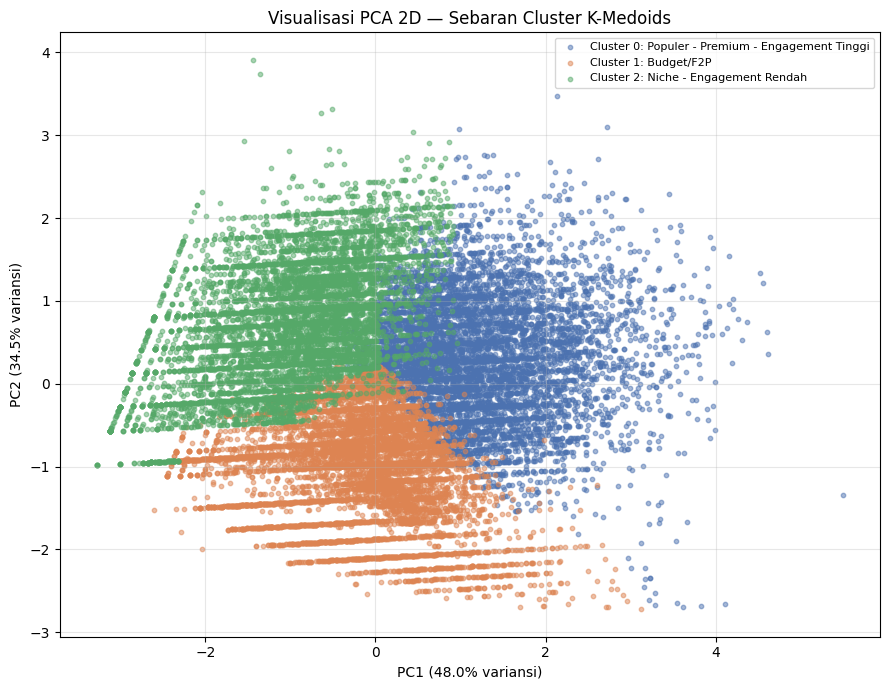

+--------------------------------------+-------------------------------------------------------------------------------------+
| Keterangan                           | Nilai                                                                               |
+======================================+=====================================================================================+
| Total variansi terjelaskan (PC1+PC2) | 82.45%                                                                              |
+--------------------------------------+-------------------------------------------------------------------------------------+
| Catatan                              | PCA murni untuk visualisasi 2D dari ruang fitur 3D — bukan untuk fitting clustering |
+--------------------------------------+-------------------------------------------------------------------------------------+


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(9, 7))
for cid in sorted(np.unique(labels_final)):
    mask = labels_final == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5,
               color=warna_cluster.get(cid, 'gray'), label=f"Cluster {cid}: {label_map[cid]}")
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variansi)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variansi)")
ax.set_title("Visualisasi PCA 2D — Sebaran Cluster K-Medoids")
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M1_pca_cluster.png', dpi=150)
section("M.1 — PCA 2D: Sebaran Cluster dalam Ruang Fitur")
plt.show()
kv_table({"Total variansi terjelaskan (PC1+PC2)": f"{sum(var_explained)*100:.2f}%",
    "Catatan": "PCA murni untuk visualisasi 2D dari ruang fitur 3D — bukan untuk fitting clustering",})

FASE 10 SECTION L - SILLOUETTE DIAGRAM


------------------------------------------------------------------------------
 M.2 — Silhouette Diagram per Cluster
------------------------------------------------------------------------------


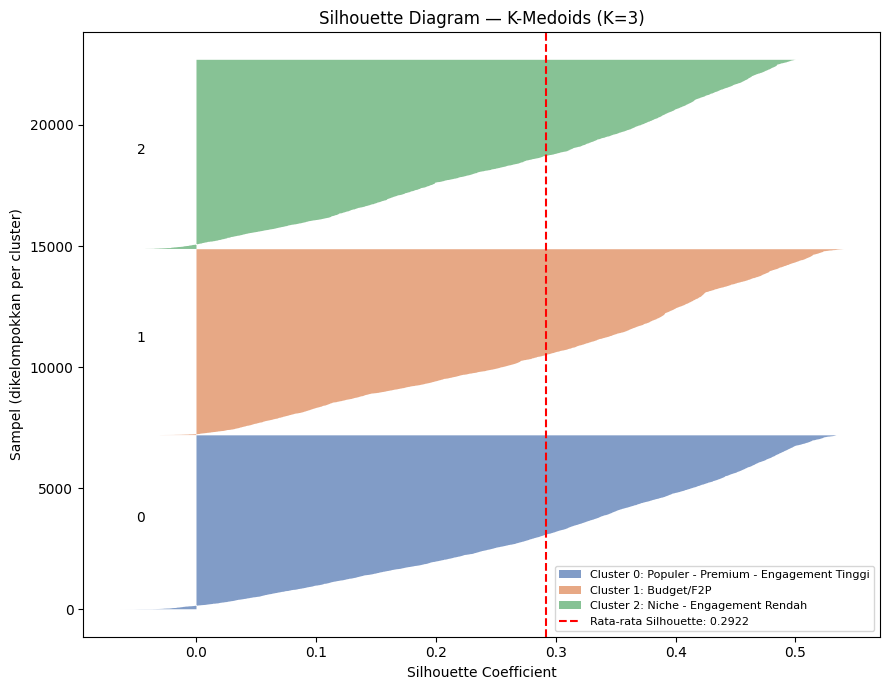

In [ ]:
sample_silhouette = silhouette_samples(X_scaled, labels_final)
sil_avg = silhouette_score(X_scaled, labels_final)
fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
for cid in sorted(np.unique(labels_final)):
    nilai_cluster = np.sort(sample_silhouette[labels_final == cid])
    ukuran_cluster = len(nilai_cluster)
    y_upper = y_lower + ukuran_cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, nilai_cluster,
                      facecolor=warna_cluster.get(cid, 'gray'), alpha=0.7,
                      label=f"Cluster {cid}: {label_map[cid]}")
    ax.text(-0.05, y_lower + ukuran_cluster / 2, str(cid))
    y_lower = y_upper + 10
ax.axvline(x=sil_avg, color='red', linestyle='--', label=f"Rata-rata Silhouette: {sil_avg:.4f}")
ax.set_xlabel("Silhouette Coefficient"); ax.set_ylabel("Sampel (dikelompokkan per cluster)")
ax.set_title("Silhouette Diagram — K-Medoids (K=3)")
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M2_silhouette_diagram.png', dpi=150)
section("M.2 — Silhouette Diagram per Cluster")
plt.show()

FASE 10 SECTION L - Boxplot per Cluster


------------------------------------------------------------------------------
 M.3 — Boxplot Distribusi Fitur per Cluster (Skala Asli)
------------------------------------------------------------------------------


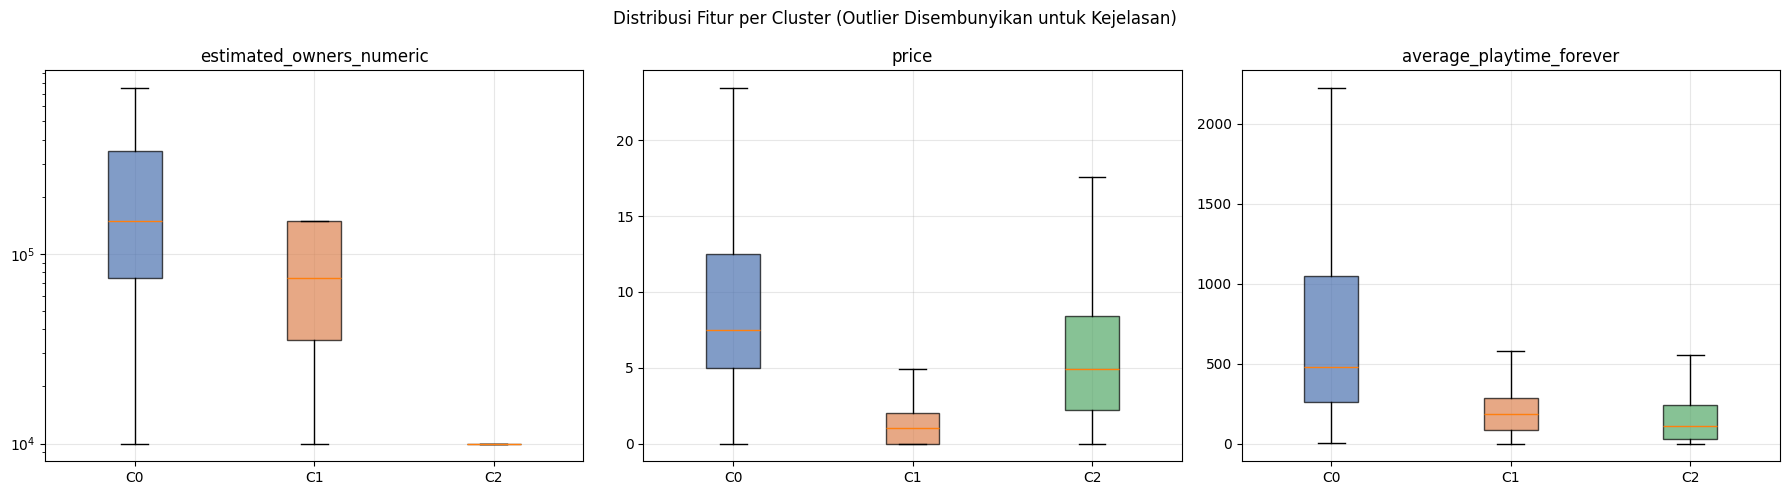

In [ ]:
import matplotlib
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, kol in enumerate(FEATURE_COLS):
    data_per_cluster = [df_final_labeled[df_final_labeled['cluster_final'] == cid][kol]
                        for cid in sorted(df_final_labeled['cluster_final'].unique())]
    if tuple(map(int, matplotlib.__version__.split('.')[:2])) >= (3, 9):
        bp = axes[i].boxplot(data_per_cluster, patch_artist=True, showfliers=False,
                              tick_labels=[f"C{cid}" for cid in sorted(df_final_labeled['cluster_final'].unique())])
    else:
        bp = axes[i].boxplot(data_per_cluster, patch_artist=True, showfliers=False,
                              labels=[f"C{cid}" for cid in sorted(df_final_labeled['cluster_final'].unique())])
    for patch, cid in zip(bp['boxes'], sorted(df_final_labeled['cluster_final'].unique())):
        patch.set_facecolor(warna_cluster.get(cid, 'gray'))
        patch.set_alpha(0.7)
    axes[i].set_title(kol)
    if kol == 'estimated_owners_numeric':
        axes[i].set_yscale('log')
    axes[i].grid(alpha=0.3)
plt.suptitle("Distribusi Fitur per Cluster (Outlier Disembunyikan untuk Kejelasan)")
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M3_boxplot_per_cluster.png', dpi=150)

section("M.3 — Boxplot Distribusi Fitur per Cluster (Skala Asli)")
plt.show()

FASE 10 SECTION L - RADAR CHART


------------------------------------------------------------------------------
 M.4 — Radar Chart: Profil Multi-Dimensi per Cluster
------------------------------------------------------------------------------


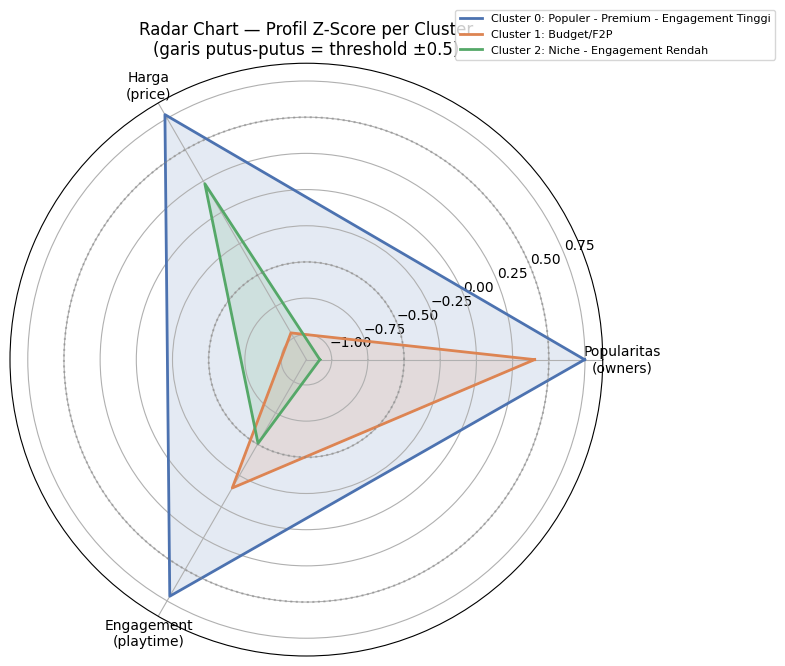

In [ ]:
# P1 — Sejajarkan index & hitung profil z-score per cluster
df_final_labeled_z = df_final_labeled.copy()
df_scaled_aligned = df_scaled_features.loc[df_final_labeled_z.index]
assert df_scaled_aligned.index.equals(df_final_labeled_z.index), \
    "GAGAL: index df_scaled_features tidak sejajar dengan df_final_labeled!"
df_final_labeled_z[[f'{k}_z' for k in FEATURE_COLS]] = df_scaled_aligned[FEATURE_COLS].values
ringkasan_zscore_radar = df_final_labeled_z.groupby('cluster_final')[[f'{k}_z' for k in FEATURE_COLS]].mean()
# P2 — Buat & simpan radar chart
kategori = ['Popularitas\n(owners)', 'Harga\n(price)', 'Engagement\n(playtime)']
angles = np.linspace(0, 2 * np.pi, len(kategori), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cid in sorted(ringkasan_zscore_radar.index):
    nilai = ringkasan_zscore_radar.loc[cid].tolist()
    nilai += nilai[:1]
    ax.plot(angles, nilai, linewidth=2, label=f"Cluster {cid}: {label_map[cid]}", color=warna_cluster.get(cid, 'gray'))
    ax.fill(angles, nilai, alpha=0.15, color=warna_cluster.get(cid, 'gray'))
ax.set_xticks(angles[:-1]); ax.set_xticklabels(kategori)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=-0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_title("Radar Chart — Profil Z-Score per Cluster\n(garis putus-putus = threshold ±0.5)")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M4_radar_profil_cluster.png', dpi=150)
section("M.4 — Radar Chart: Profil Multi-Dimensi per Cluster")
plt.show()

FASE 10 SECTION L - Bar Chart Distribusi Label


------------------------------------------------------------------------------
 M.5 — Distribusi Jumlah Game per Label Cluster
------------------------------------------------------------------------------


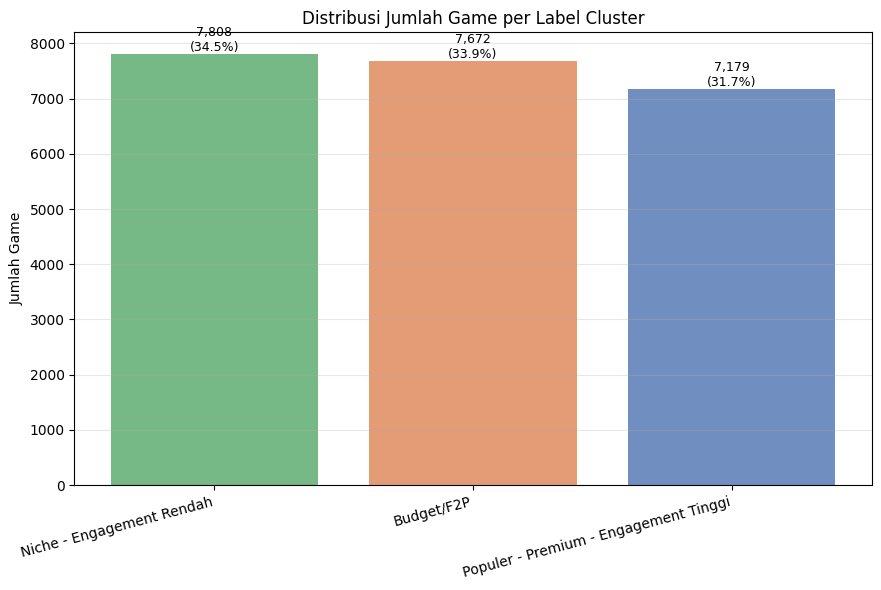

In [ ]:
distribusi = df_final_labeled['label_cluster'].value_counts()
warna_bar = [warna_cluster.get([k for k, v in label_map.items() if v == lbl][0], 'gray') for lbl in distribusi.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(distribusi.index, distribusi.values, color=warna_bar, alpha=0.8)
for bar, val in zip(bars, distribusi.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:,}\n({val/len(df_final_labeled)*100:.1f}%)",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Jumlah Game")
ax.set_title("Distribusi Jumlah Game per Label Cluster")
plt.xticks(rotation=15, ha='right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M5_distribusi_label.png', dpi=150)

section("M.5 — Distribusi Jumlah Game per Label Cluster")
plt.show()

FASE 10 SECTION L - Perbandingan Metrik K-Means vs K-Medoids


------------------------------------------------------------------------------
 M.6 — Perbandingan Metrik Evaluasi K-Means vs K-Medoids
------------------------------------------------------------------------------
+----------------------------------------------------------+---------+
| Keterangan                                               | Nilai   |
+==========================================================+=========+
| Index df_hasil_fitting sejajar dengan df_scaled_features | YA      |
+----------------------------------------------------------+---------+


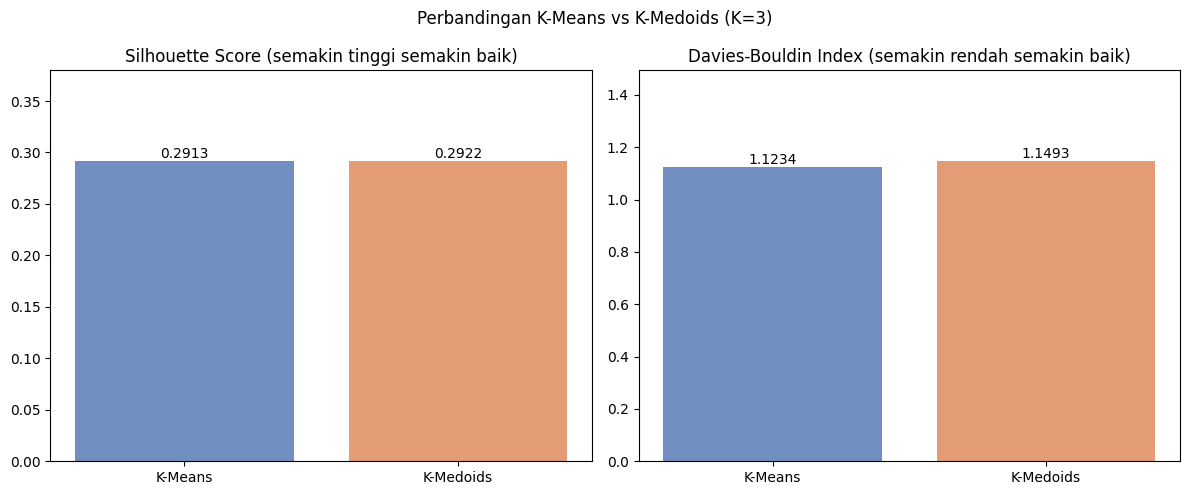

In [ ]:
# P1 — Muat hasil fitting & validasi index (sama seperti pola Section J)
df_hasil_fitting = muat_checkpoint('clustering', '08_hasil_kmeans_vs_kmedoids.csv',
                                    kolom_list_literal=['genres', 'categories', 'tags'])
index_sejajar_M6 = df_hasil_fitting.index.equals(df_scaled_features.index)
if not index_sejajar_M6:
    df_hasil_fitting = df_hasil_fitting.loc[df_scaled_features.index]
    assert df_hasil_fitting.index.equals(df_scaled_features.index), \
        "GAGAL: penyelarasan index df_hasil_fitting tidak berhasil"
# P2 — Hitung ulang metrik kedua model
sil_km  = silhouette_score(X_scaled, df_hasil_fitting['cluster_kmeans'])
dbi_km  = davies_bouldin_score(X_scaled, df_hasil_fitting['cluster_kmeans'])
sil_kmd = silhouette_score(X_scaled, df_hasil_fitting['cluster_kmedoids'])
dbi_kmd = davies_bouldin_score(X_scaled, df_hasil_fitting['cluster_kmedoids'])
# P3 — Buat & simpan bar chart perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['K-Means', 'K-Medoids'], [sil_km, sil_kmd], color=['#4C72B0', '#DD8452'], alpha=0.8)
axes[0].set_title("Silhouette Score (semakin tinggi semakin baik)")
axes[0].set_ylim(0, max(sil_km, sil_kmd) * 1.3)
for i, v in enumerate([sil_km, sil_kmd]):
    axes[0].text(i, v, f"{v:.4f}", ha='center', va='bottom')
axes[1].bar(['K-Means', 'K-Medoids'], [dbi_km, dbi_kmd], color=['#4C72B0', '#DD8452'], alpha=0.8)
axes[1].set_title("Davies-Bouldin Index (semakin rendah semakin baik)")
axes[1].set_ylim(0, max(dbi_km, dbi_kmd) * 1.3)
for i, v in enumerate([dbi_km, dbi_kmd]):
    axes[1].text(i, v, f"{v:.4f}", ha='center', va='bottom')
plt.suptitle("Perbandingan K-Means vs K-Medoids (K=3)")
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M6_perbandingan_model.png', dpi=150)
section("M.6 — Perbandingan Metrik Evaluasi K-Means vs K-Medoids")
kv_table({"Index df_hasil_fitting sejajar dengan df_scaled_features": "YA" if index_sejajar_M6 else "TIDAK -- perlu penyelarasan"})
plt.show()

FASE 10 SECTION L - Distribusi Anggota Cluster Side-by-Side


------------------------------------------------------------------------------
 M.7 — Distribusi Anggota Cluster: K-Means vs K-Medoids
------------------------------------------------------------------------------


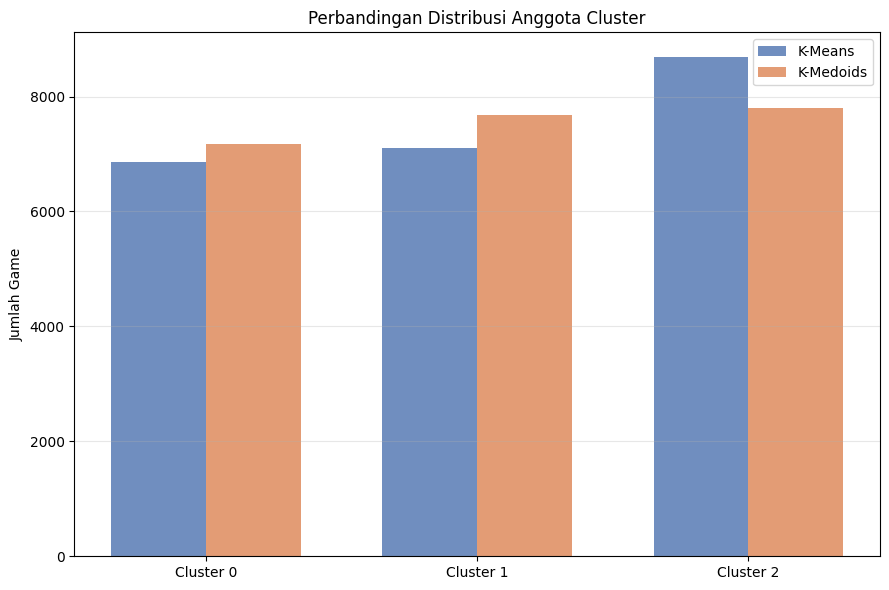

In [ ]:
vc_km_full  = df_hasil_fitting['cluster_kmeans'].value_counts().sort_index()
vc_kmd_full = df_hasil_fitting['cluster_kmedoids'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(vc_km_full))
lebar = 0.35
ax.bar(x - lebar/2, vc_km_full.values, lebar, label='K-Means', color='#4C72B0', alpha=0.8)
ax.bar(x + lebar/2, vc_kmd_full.values, lebar, label='K-Medoids', color='#DD8452', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"Cluster {c}" for c in vc_km_full.index])
ax.set_ylabel("Jumlah Game")
ax.set_title("Perbandingan Distribusi Anggota Cluster")
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M7_distribusi_kmeans_vs_kmedoids.png', dpi=150)
section("M.7 — Distribusi Anggota Cluster: K-Means vs K-Medoids")
plt.show()

FASE 10 SECTION L - SCATTER 3D


------------------------------------------------------------------------------
 M.8 — Scatter 3D: Sebaran Cluster pada 3 Fitur Asli
------------------------------------------------------------------------------


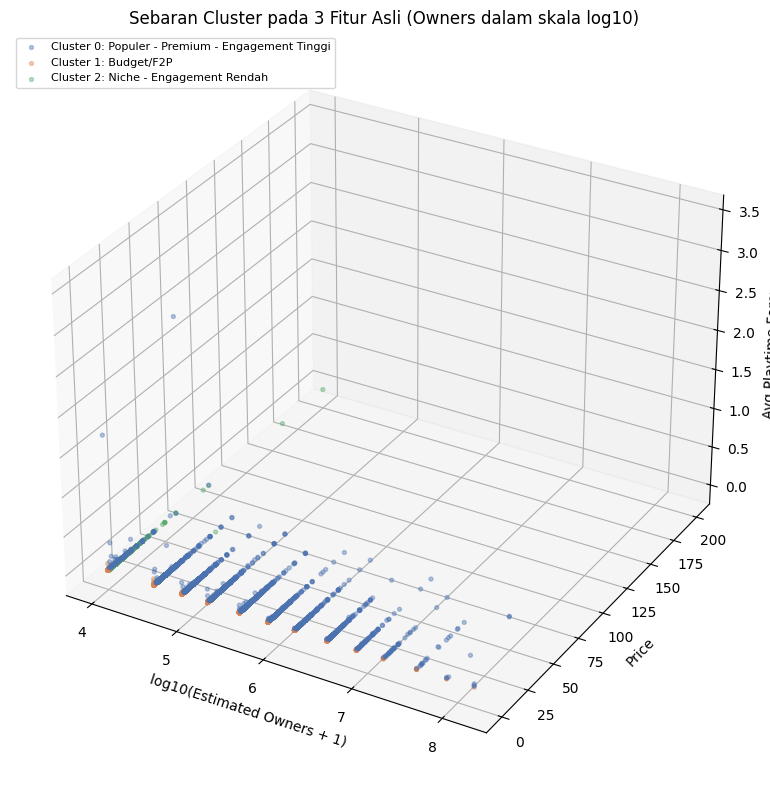

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for cid in sorted(df_final_labeled['cluster_final'].unique()):
    subset = df_final_labeled[df_final_labeled['cluster_final'] == cid]
    ax.scatter(
        np.log10(subset['estimated_owners_numeric'] + 1),
        subset['price'], subset['average_playtime_forever'],
        s=8, alpha=0.4, color=warna_cluster.get(cid, 'gray'), label=f"Cluster {cid}: {label_map[cid]}")
ax.set_xlabel('log10(Estimated Owners + 1)'); ax.set_ylabel('Price'); ax.set_zlabel('Avg Playtime Forever')
ax.set_title("Sebaran Cluster pada 3 Fitur Asli (Owners dalam skala log10)")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(FOLDERS['visualisasi'] + 'viz_M8_scatter3d_cluster.png', dpi=150)
section("M.8 — Scatter 3D: Sebaran Cluster pada 3 Fitur Asli")
plt.show()

FASE 10 SECTION L - Penutup — Simpan Bukti Proses, Manifest, Log

In [ ]:
# P1 — Daftar semua file visualisasi yang dihasilkan
daftar_file_visualisasi = [
    'viz_M1_pca_cluster.png', 'viz_M2_silhouette_diagram.png', 'viz_M3_boxplot_per_cluster.png',
    'viz_M4_radar_profil_cluster.png', 'viz_M5_distribusi_label.png', 'viz_M6_perbandingan_model.png',
    'viz_M7_distribusi_kmeans_vs_kmedoids.png', 'viz_M8_scatter3d_cluster.png',
]

# P2 — Catat bukti proses
simpan_bukti_proses('bukti_M_visualisasi_lengkap.csv', {
    'tahap': 'M. Visualisasi Lengkap', 'jumlah_visualisasi': len(daftar_file_visualisasi),
    'daftar_file': ', '.join(daftar_file_visualisasi),
    'variansi_pca_pc1_pc2': f"{sum(var_explained)*100:.2f}%", 'silhouette_final': round(sil_avg, 4),
    'waktu_eksekusi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
})

# P3 — Catat manifest & log
tulis_manifest(tahap='M. Visualisasi Lengkap', nama_file=', '.join(daftar_file_visualisasi),
    path_file=FOLDERS['visualisasi'], df=df_final_labeled,
    deskripsi='Visualisasi lengkap: PCA 2D, silhouette diagram, boxplot per cluster, radar chart z-score, '
              'distribusi label, perbandingan K-Means vs K-Medoids, scatter 3D')
tulis_log(tahap='M. Visualisasi Lengkap',
    keterangan=f'{len(daftar_file_visualisasi)} visualisasi standar penelitian clustering berhasil dibuat',
    baris_masuk=len(df_final_labeled), baris_keluar=len(df_final_labeled))

footer(note=f"{len(daftar_file_visualisasi)} file visualisasi tersimpan di 07_visualisasi/. "
            "Pipeline penelitian selesai — siap untuk penulisan bab hasil dan pembahasan.",
       saved_to=", ".join(daftar_file_visualisasi))

------------------------------------------------------------------------------
 Output disimpan : viz_M1_pca_cluster.png, viz_M2_silhouette_diagram.png, viz_M3_boxplot_per_cluster.png, viz_M4_radar_profil_cluster.png, viz_M5_distribusi_label.png, viz_M6_perbandingan_model.png, viz_M7_distribusi_kmeans_vs_kmedoids.png, viz_M8_scatter3d_cluster.png
 Catatan         : 8 file visualisasi tersimpan di 07_visualisasi/. Pipeline penelitian selesai — siap untuk penulisan bab hasil dan pembahasan.
 Waktu eksekusi  : 2026-08-10 06:07:32

